# KBO 롯데 자이언츠 What-if 프로젝트 — 탐색적 데이터 분석 (EDA)

**분석 순서**
1. 경기 단위 개요 (`games.csv`) — 데이터 범위·시즌 구조 파악
2. 타석 이벤트 분포 (`plate_appearances.csv`) — 타석 결과·상황 패턴
3. 모델 피처·라벨 분석 (`model_master_pa_extended_eligible.csv`) — 피처 분포·상관관계·라벨 균형
4. WE/RE 상태 공간 (`we_table.csv`, `re_table.csv`) — 승리/득점 기대값 시각화

In [14]:
import warnings
warnings.filterwarnings('ignore')

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import matplotlib as mpl

sns.set_style('whitegrid')

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


DATA = Path('../kbo_pipeline/data/processed')
print('준비 완료')

준비 완료


---
## 1단계 — 경기 단위 개요 (`games.csv`)

In [15]:
# games_detail.csv에 winner_team_code 포함
games = pd.read_csv(DATA / 'games_detail.csv')
games['season'] = games['game_id'].astype(str).str[:4].astype(int)
print(f'경기 수: {len(games):,}   시즌: {sorted(games["season"].unique())}')
games.head(3)

경기 수: 8,907   시즌: [np.int64(2008), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,game_id,game_date,game_time,stadium,away_team_code,away_team_name,away_team_full_name,home_team_code,home_team_name,home_team_full_name,away_starting_pitcher_pcode,home_starting_pitcher_pcode,away_score,home_score,winner_team_code,status_code,cancel_flag,season
0,20080601HTOB0,20080601,17:00,잠실,HT,KIA,KIA 타이거즈,OB,두산,두산 베어스,78627.0,75230.0,6.0,2.0,HT,4,N,2008
1,20080601LGHH0,20080601,14:00,청주,LG,LG,LG 트윈스,HH,한화,한화 이글스,77199.0,97336.0,8.0,2.0,LG,4,N,2008
2,20080601LTWO0,20080601,17:00,목동,LT,롯데,롯데 자이언츠,WO,히어로즈,키움 히어로즈,70434.0,76350.0,8.0,3.0,LT,4,N,2008


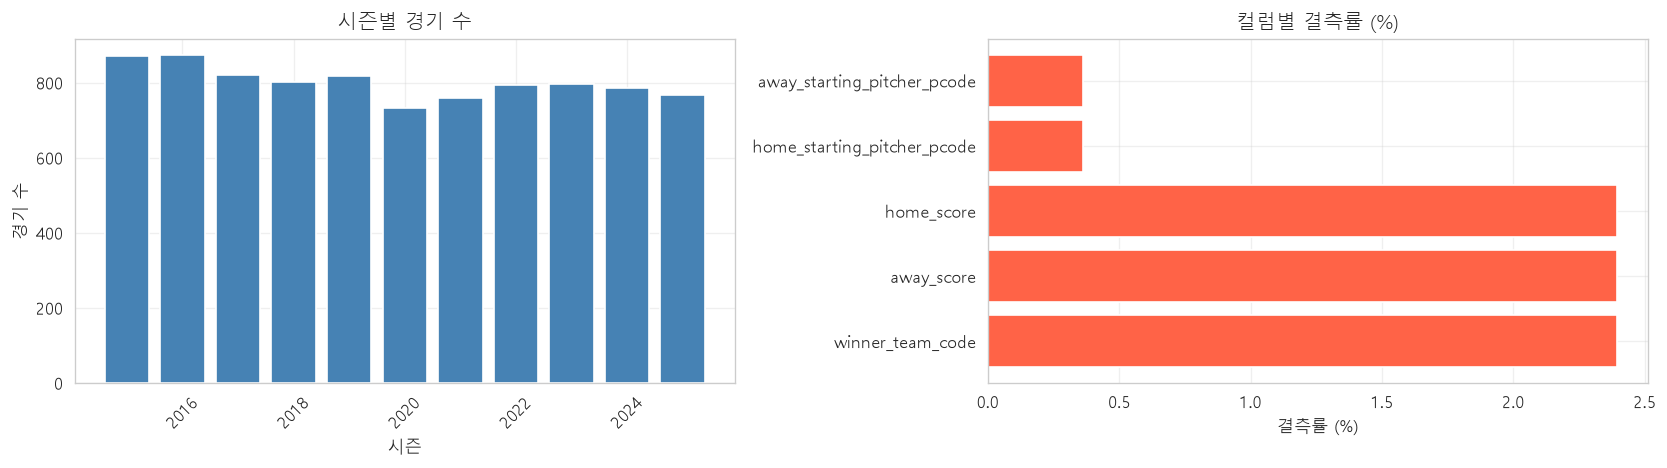

In [19]:
games = games[
    games["season"].between(2015, 2025)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 시즌별 경기 수
season_cnt = games['season'].value_counts().sort_index()
axes[0].bar(season_cnt.index, season_cnt.values, color='steelblue')
axes[0].set_title('시즌별 경기 수')
axes[0].set_xlabel('시즌')
axes[0].set_ylabel('경기 수')
axes[0].tick_params(axis='x', rotation=45)

# 컬럼별 결측률
missing = (games.isnull().sum() / len(games) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing):
    axes[1].barh(missing.index, missing.values, color='tomato')
    axes[1].set_title('컬럼별 결측률 (%)')
    axes[1].set_xlabel('결측률 (%)')
else:
    axes[1].text(0.5, 0.5, '결측치 없음', ha='center', va='center', fontsize=14)
    axes[1].set_title('컬럼별 결측률 (%)')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [20]:
games["season"].value_counts().sort_index()

season
2015    871
2016    873
2017    820
2018    801
2019    818
2020    732
2021    760
2022    794
2023    796
2024    785
2025    768
Name: count, dtype: int64

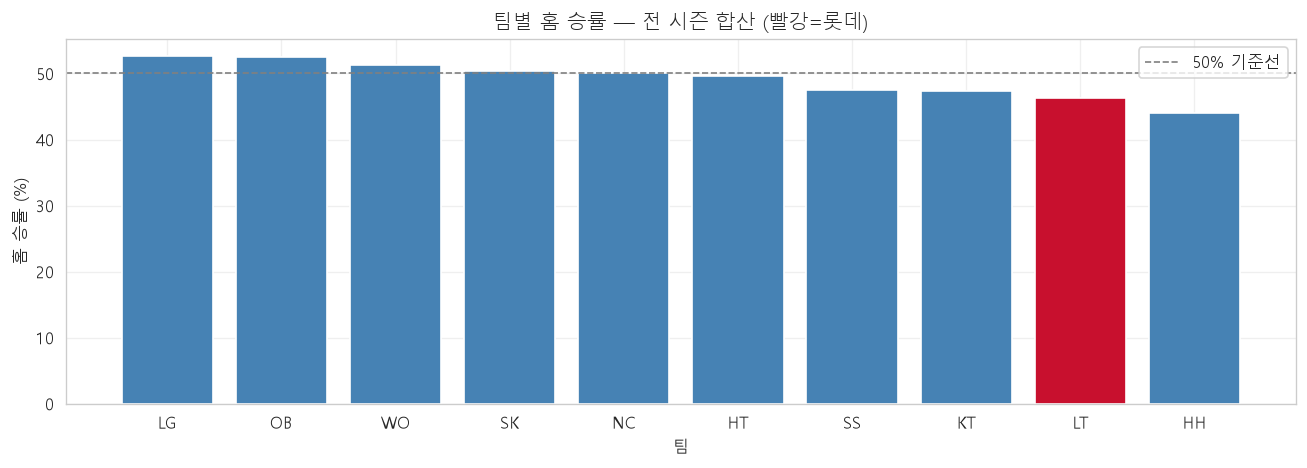

In [21]:
# 팀별 홈 승률
winner_col = 'winner_team_code'
home_col   = 'home_team_code'
away_col   = 'away_team_code'

total    = games[home_col].value_counts()
wins     = games[games[winner_col] == games[home_col]][home_col].value_counts()
win_rate = (wins / total * 100).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#C8102E' if t == 'LT' else 'steelblue' for t in win_rate.index]
ax.bar(win_rate.index, win_rate.values, color=colors)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% 기준선')
ax.set_title('팀별 홈 승률 — 전 시즌 합산 (빨강=롯데)')
ax.set_xlabel('팀')
ax.set_ylabel('홈 승률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

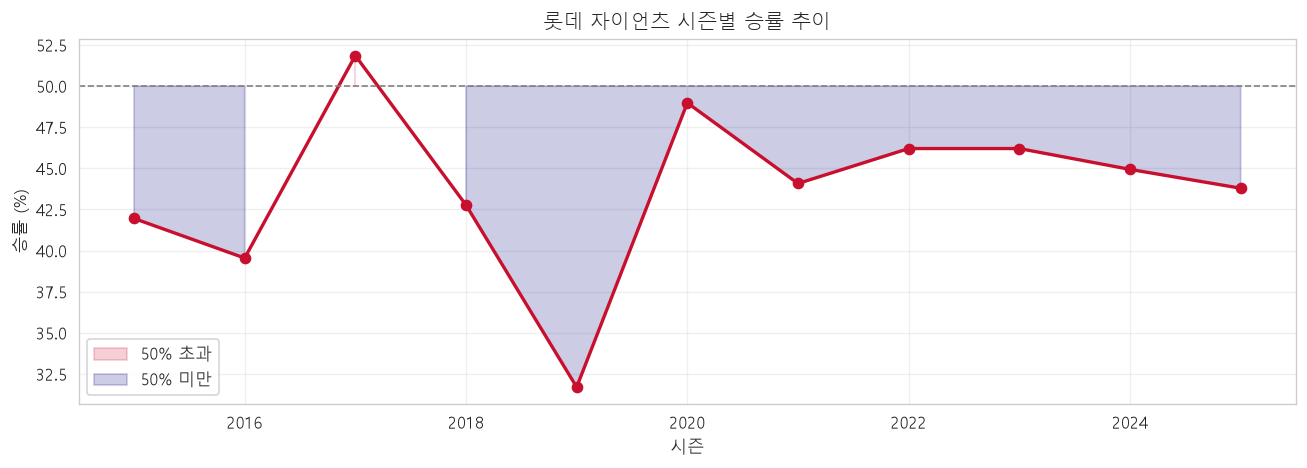

In [22]:
# 롯데 시즌별 승률 추이
lotte = games[(games[home_col] == 'LT') | (games[away_col] == 'LT')].copy()
lotte['lotte_win'] = (lotte[winner_col] == 'LT').astype(float)
lotte_rate = lotte.groupby('season')['lotte_win'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lotte_rate.index, lotte_rate.values, marker='o', color='#C8102E', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=1)
ax.fill_between(lotte_rate.index, 50, lotte_rate.values,
                where=lotte_rate.values >= 50, alpha=0.2, color='#C8102E', label='50% 초과')
ax.fill_between(lotte_rate.index, 50, lotte_rate.values,
                where=lotte_rate.values < 50, alpha=0.2, color='navy', label='50% 미만')
ax.set_title('롯데 자이언츠 시즌별 승률 추이')
ax.set_xlabel('시즌')
ax.set_ylabel('승률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2단계 — 타석 이벤트 분포 (`plate_appearances.csv`)

In [26]:
pa = pd.read_csv(DATA / 'plate_appearances.csv')
pa['season'] = pa['game_id'].astype(str).str[:4].astype(int)

pa = pa[
    pa["season"].between(2015, 2025)
].copy()
print(f'타석 수: {len(pa):,}   컬럼: {len(pa.columns)}개')
pa[['game_id','inning','home_or_away','pa_result_type','outs_before',
    'base1_before','base2_before','base3_before','batting_team_code']].head(3)

타석 수: 661,136   컬럼: 57개


,game_id,inning,home_or_away,pa_result_type,outs_before,base1_before,base2_before,base3_before,batting_team_code
0,20150307HTNC0,1,0,single,0,0,0,0,HT
1,20150307HTNC0,1,0,single,0,1,0,0,HT
2,20150307HTNC0,1,0,out,1,0,0,0,HT


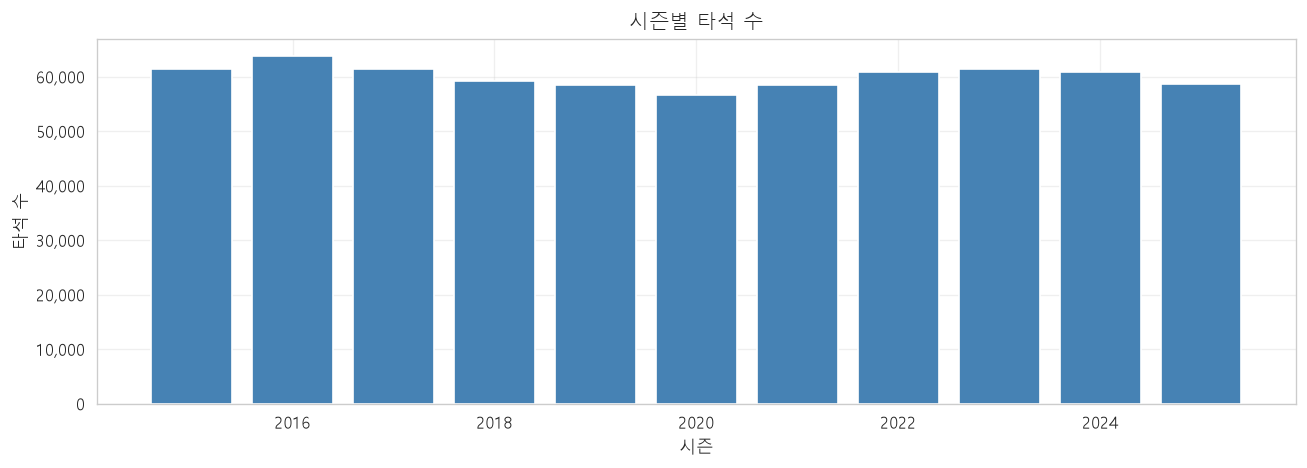

In [27]:
# 시즌별 타석 수
fig, ax = plt.subplots(figsize=(11, 4))
cnt = pa['season'].value_counts().sort_index()
ax.bar(cnt.index, cnt.values, color='steelblue')
ax.set_title('시즌별 타석 수')
ax.set_xlabel('시즌')
ax.set_ylabel('타석 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

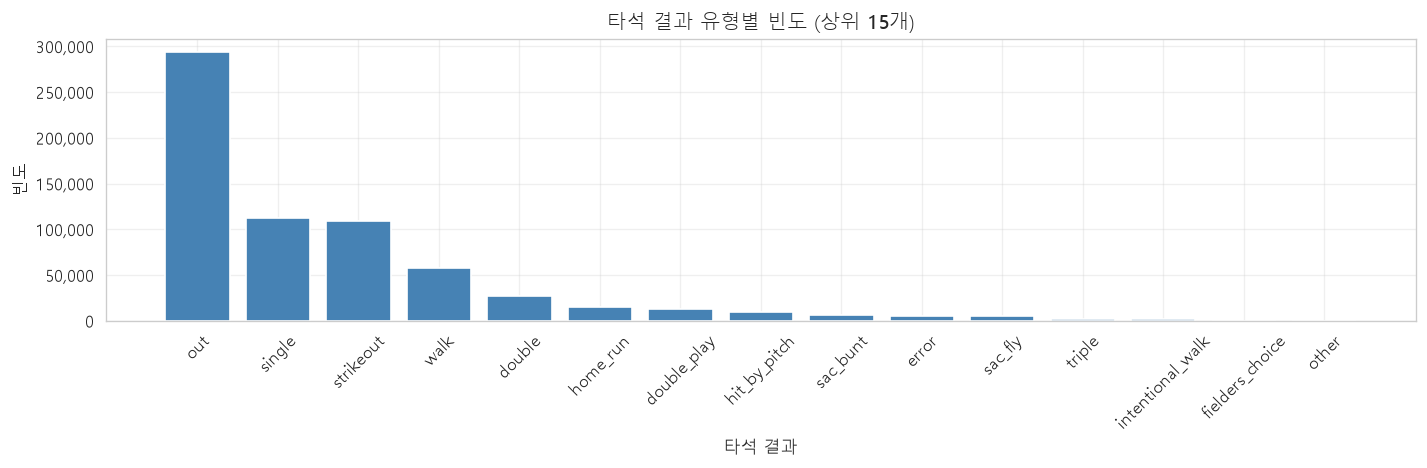

In [28]:
# 타석 결과 분포 (pa_result_type)
top_results = pa['pa_result_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top_results.index.astype(str), top_results.values, color='steelblue')
ax.set_title('타석 결과 유형별 빈도 (상위 15개)')
ax.set_xlabel('타석 결과')
ax.set_ylabel('빈도')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

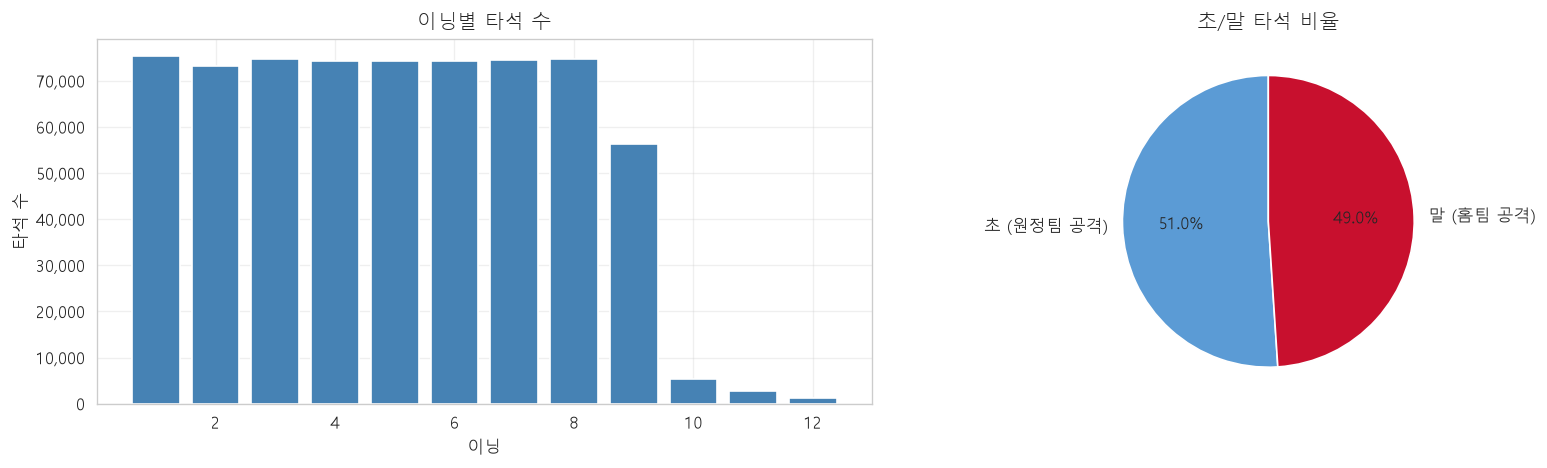

In [29]:
# 이닝별 타석 수 & 초/말 비율
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 이닝별
inning_cnt = pa['inning'].value_counts().sort_index()
axes[0].bar(inning_cnt.index, inning_cnt.values, color='steelblue')
axes[0].set_title('이닝별 타석 수')
axes[0].set_xlabel('이닝')
axes[0].set_ylabel('타석 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 초/말 비율
top_bot = pa['home_or_away'].map({0: '초 (원정팀 공격)', 1: '말 (홈팀 공격)'}).value_counts()
palette = ['#5B9BD5', '#C8102E'] if len(top_bot) == 2 else sns.color_palette('Set2', len(top_bot))
axes[1].pie(top_bot.values, labels=top_bot.index, autopct='%1.1f%%',
            colors=palette, startangle=90)
axes[1].set_title('초/말 타석 비율')

plt.tight_layout()
plt.show()

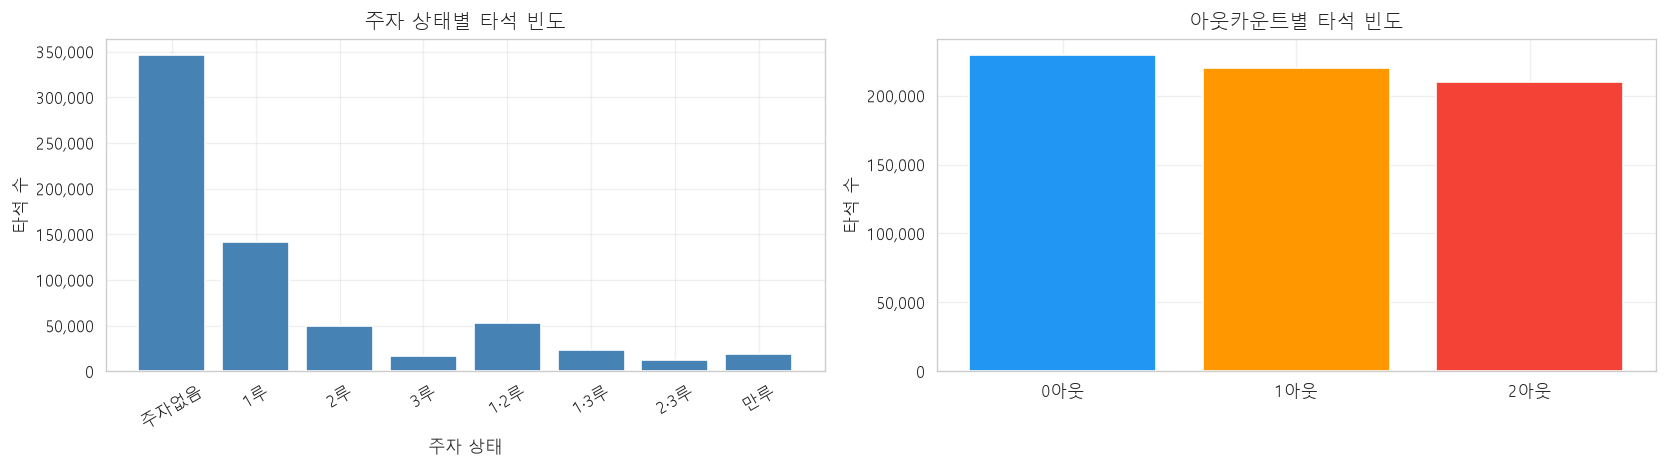

In [30]:
# 주자 상태별 빈도
pa['주자상태코드'] = (pa['base1_before'].fillna(0).clip(0,1).astype(int).astype(str)
                    + pa['base2_before'].fillna(0).clip(0,1).astype(int).astype(str)
                    + pa['base3_before'].fillna(0).clip(0,1).astype(int).astype(str))
label_map = {
    '000':'주자없음','100':'1루','010':'2루','001':'3루',
    '110':'1·2루','101':'1·3루','011':'2·3루','111':'만루'
}
pa['주자상태'] = pa['주자상태코드'].map(label_map).fillna(pa['주자상태코드'])

order = ['주자없음','1루','2루','3루','1·2루','1·3루','2·3루','만루']
state_cnt = pa['주자상태'].value_counts().reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(state_cnt.index, state_cnt.values, color='steelblue')
axes[0].set_title('주자 상태별 타석 빈도')
axes[0].set_xlabel('주자 상태')
axes[0].set_ylabel('타석 수')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 아웃카운트별
outs_cnt = pa['outs_before'].value_counts().sort_index()
outs_012 = outs_cnt.reindex([0,1,2], fill_value=0)
axes[1].bar(['0아웃','1아웃','2아웃'], outs_012.values,
            color=['#2196F3','#FF9800','#F44336'])
axes[1].set_title('아웃카운트별 타석 빈도')
axes[1].set_ylabel('타석 수')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

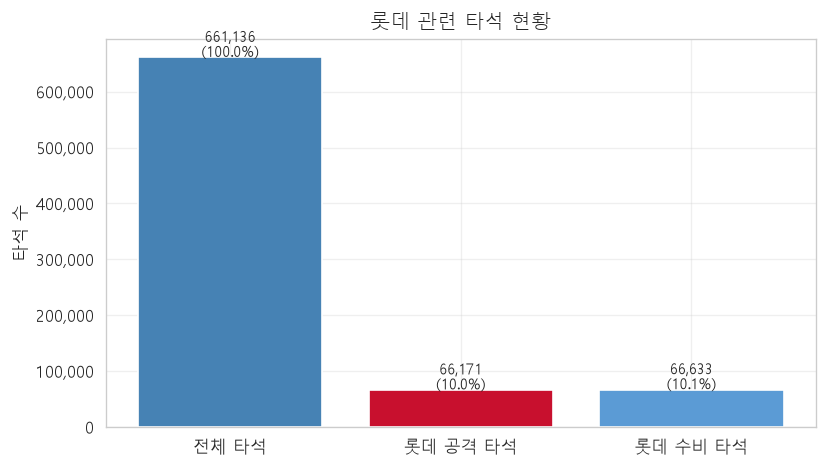

In [31]:
# 롯데 관련 타석 비율
lotte_bat  = pa['is_lotte_batting'].sum()
lotte_fld  = pa['is_lotte_fielding'].sum()
total_pa   = len(pa)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['전체 타석', '롯데 공격 타석', '롯데 수비 타석'],
       [total_pa, lotte_bat, lotte_fld],
       color=['steelblue','#C8102E','#5B9BD5'])
ax.set_title('롯데 관련 타석 현황')
ax.set_ylabel('타석 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate([total_pa, lotte_bat, lotte_fld]):
    ax.text(i, v + 1000, f'{v:,}\n({v/total_pa*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3단계 — 모델 피처·라벨 분석 (`model_master_pa_extended_eligible.csv`)

> 파일이 크므로 핵심 컬럼만 선택 로드합니다.

In [ ]:
LOAD_COLS = [
    'game_id',
    'inning', 'home_or_away', 'outs_before',
    'base1_before', 'base2_before', 'base3_before',
    'batting_score_diff_before',
    'state_we', 'state_re',
    'late_clutch', 'scoring_position_before',
    'is_top_bool', 'is_home_batting',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before',
    'pitcher_pre_k9_before',  'pitcher_pre_bb9_before',
    'pitcher_pre_ip_before',  'pitcher_pre_games_before',
    'batter_pre_games_before','batter_pre_cum_ab',
    'batter_pre_avg_before',  'batter_pre_slg_before',
    'batter_pre_ops_before',
    'batting_team_win_label',
]

df = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=lambda c: c in LOAD_COLS,
    dtype='float32',
    low_memory=False
)
# game_id는 문자열이므로 별도 로드
df['game_id'] = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=['game_id'], dtype=str
)['game_id']
df['season'] = df['game_id'].astype(str).str[:4].astype(int)

df = df[
    df["season"].between(2015, 2025)
].copy()

print(f'로드: {len(df):,}행 × {len(df.columns)}열  메모리: {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
df.describe().T[["count","mean","std","min","max"]].round(3)

In [33]:
LOAD_COLS = [
    'game_id',
    'inning', 'home_or_away', 'outs_before',
    'base1_before', 'base2_before', 'base3_before',
    'batting_score_diff_before',
    'state_we', 'state_re',
    'late_clutch', 'scoring_position_before',
    'is_top_bool', 'is_home_batting',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before',
    'pitcher_pre_k9_before',  'pitcher_pre_bb9_before',
    'pitcher_pre_ip_before',  'pitcher_pre_games_before',
    'batter_pre_games_before','batter_pre_cum_ab',
    'batter_pre_avg_before',  'batter_pre_slg_before',
    'batter_pre_ops_before',
    'batting_team_win_label',
]

BOOL_COLS = [
    "late_clutch",
    "scoring_position_before",
    "is_top_bool",
    "is_home_batting",
]

ID_COLS = ["game_id"]

NUM_COLS = [
    c for c in LOAD_COLS
    if c not in ID_COLS + BOOL_COLS
]

df = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=lambda c: c in LOAD_COLS,
    dtype={"game_id": "string"},
    low_memory=False
)
# 시즌 생성
df["season"] = pd.to_numeric(
    df["game_id"].astype(str).str[:4],
    errors="coerce"
)

# 2015~2025만 필터링
df = df[df["season"].between(2015, 2025)].copy()
df["season"] = df["season"].astype("int16")

# 숫자 컬럼만 float32로 변환
for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

# bool 컬럼 정리
for col in BOOL_COLS:
    if col in df.columns:
        df[col] = (
            df[col]
            .map({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0,
                1: 1,
                0: 0,
            })
            .astype("float32")
        )

print(
    f"로드: {len(df):,}행 × {len(df.columns)}열  "
    f"메모리: {df.memory_usage(deep=True).sum()/1e6:.0f} MB"
)

df.describe().T[["count", "mean", "std", "min", "max"]].round(3)

로드: 687,954행 × 27열  메모리: 115 MB


,count,mean,std,min,max
inning,687954.0,4.973,2.598,1.000,12.000
home_or_away,687954.0,0.489,0.500,0.000,1.000
outs_before,687954.0,0.969,0.816,0.000,2.000
base1_before,687954.0,0.356,0.479,0.000,1.000
base2_before,687954.0,0.200,0.400,0.000,1.000
base3_before,687954.0,0.107,0.309,0.000,1.000
scoring_position_before,687954.0,0.259,0.438,0.000,1.000
late_clutch,687954.0,0.153,0.360,0.000,1.000
is_top_bool,687954.0,0.511,0.500,0.000,1.000
is_home_batting,687954.0,0.489,0.500,0.000,1.000


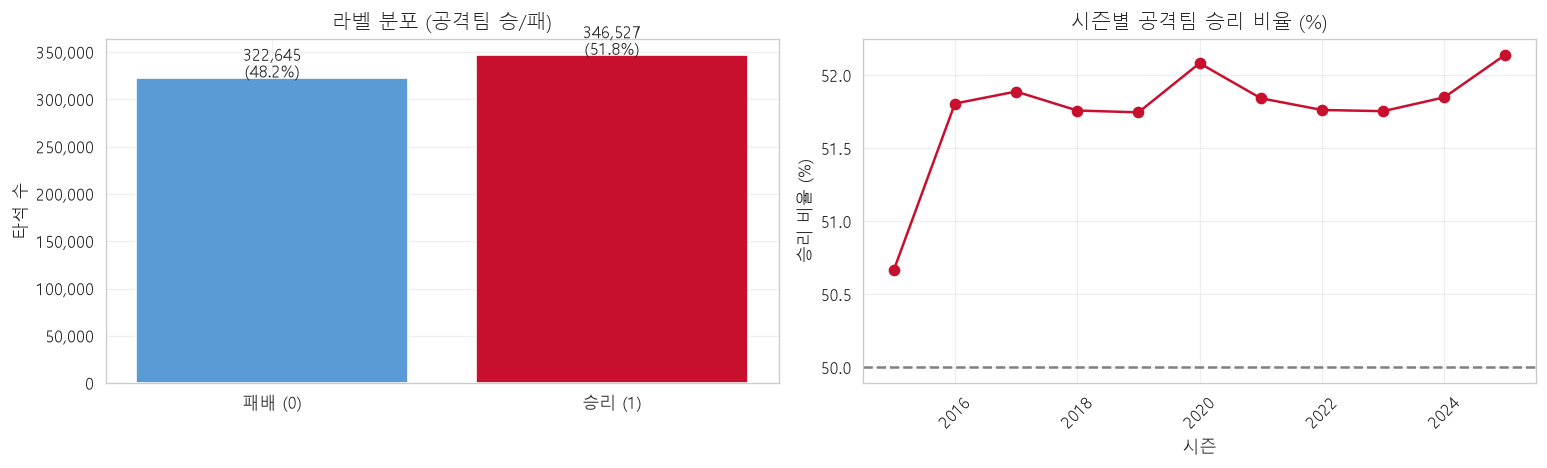

In [34]:
# 라벨 분포 (클래스 균형 확인)
label_valid = df[df['batting_team_win_label'].isin([0.0, 1.0])]['batting_team_win_label'].astype(int)
cnt = label_valid.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['패배 (0)', '승리 (1)'], cnt.values, color=['#5B9BD5','#C8102E'])
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/cnt.sum()*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('라벨 분포 (공격팀 승/패)')
axes[0].set_ylabel('타석 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

season_win = (df[df['batting_team_win_label'].isin([0.0,1.0])]
              .groupby('season')['batting_team_win_label'].mean() * 100)
axes[1].plot(season_win.index, season_win.values, marker='o', color='#C8102E')
axes[1].axhline(50, color='gray', linestyle='--')
axes[1].set_title('시즌별 공격팀 승리 비율 (%)')
axes[1].set_xlabel('시즌')
axes[1].set_ylabel('승리 비율 (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

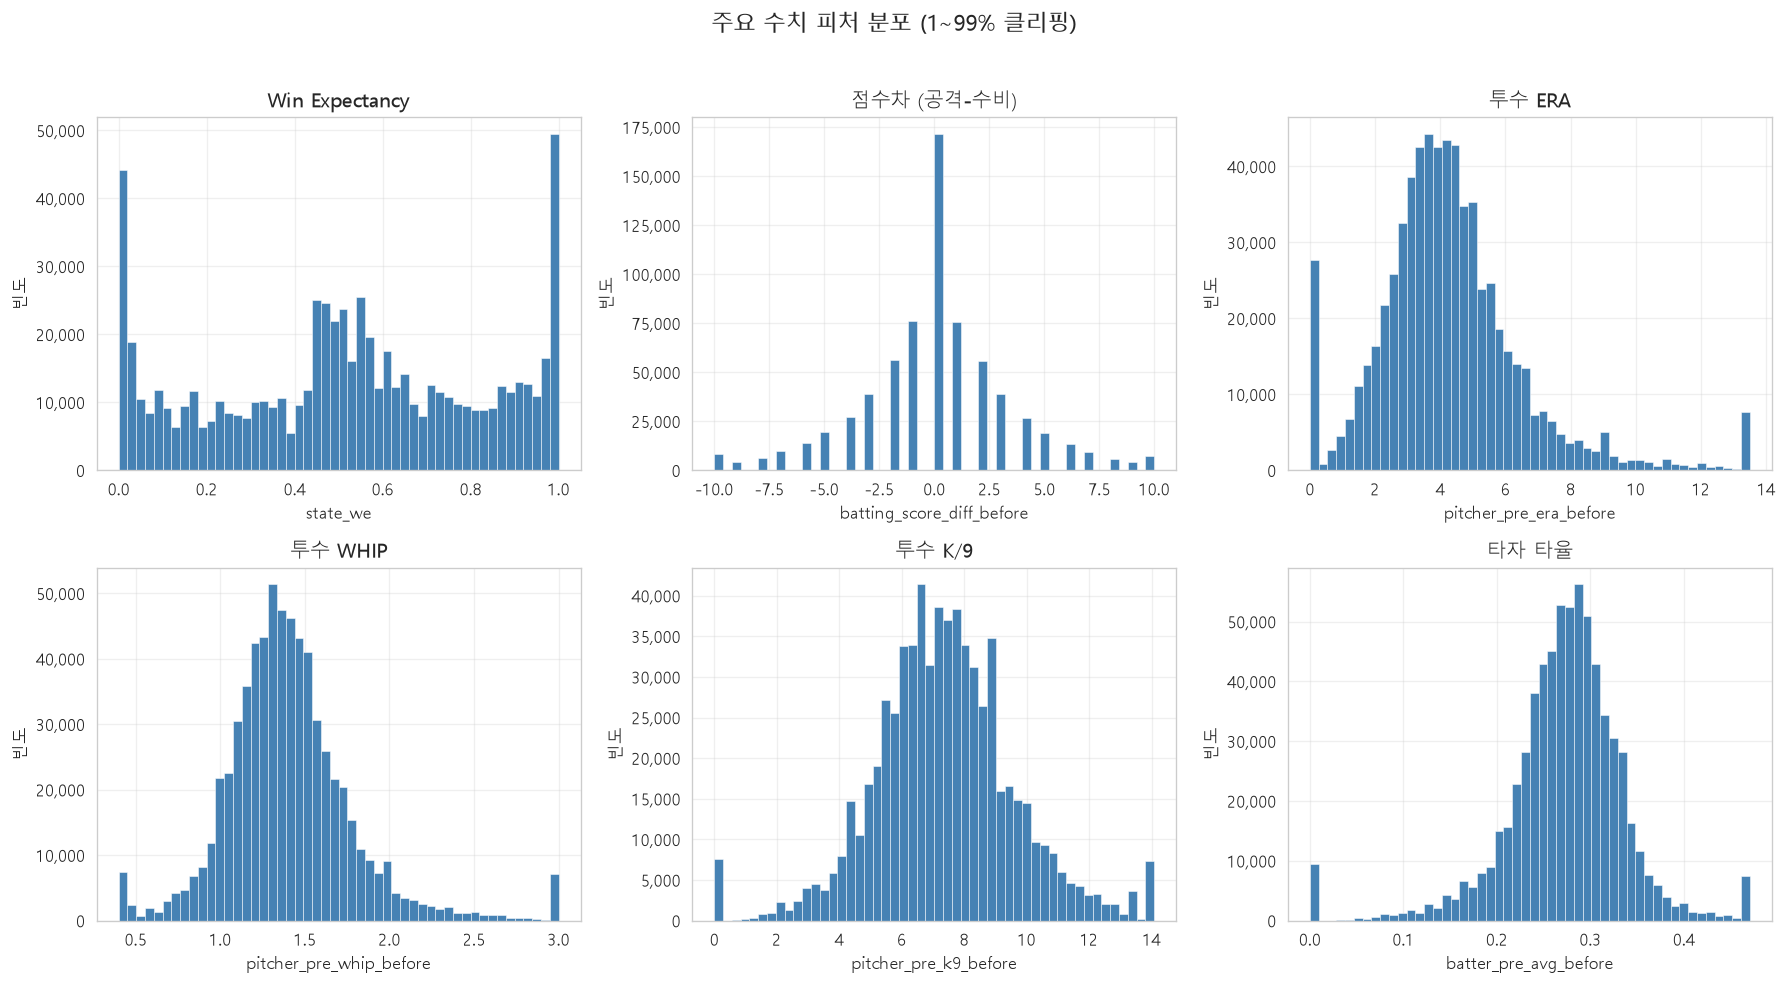

In [35]:
# 주요 수치 피처 분포 히스토그램
num_feats = [
    ('state_we',                  'Win Expectancy'),
    ('batting_score_diff_before', '점수차 (공격-수비)'),
    ('pitcher_pre_era_before',    '투수 ERA'),
    ('pitcher_pre_whip_before',   '투수 WHIP'),
    ('pitcher_pre_k9_before',     '투수 K/9'),
    ('batter_pre_avg_before',     '타자 타율'),
]
num_feats = [(c, lbl) for c, lbl in num_feats if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, lbl) in zip(axes.flatten(), num_feats):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    ax.hist(data.clip(lo, hi), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(lbl)
    ax.set_xlabel(col)
    ax.set_ylabel('빈도')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('주요 수치 피처 분포 (1~99% 클리핑)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

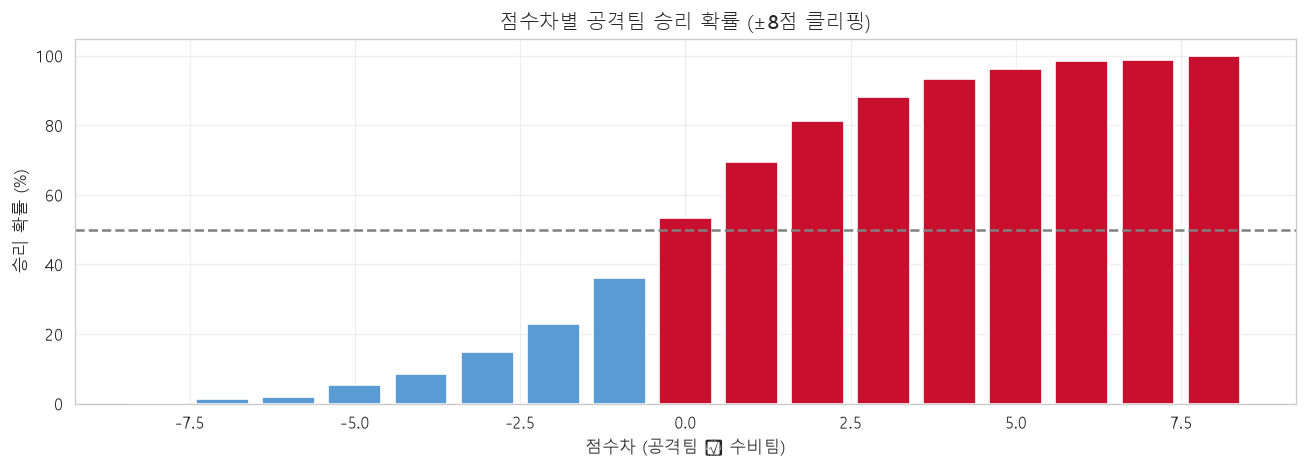

In [36]:
# 점수차별 공격팀 승리 확률
diff_win = (
    df[df['batting_team_win_label'].isin([0.0, 1.0])]
    .assign(diff_clip=df['batting_score_diff_before'].clip(-8, 8).astype(int))
    .groupby('diff_clip')['batting_team_win_label']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#C8102E' if v >= 50 else '#5B9BD5' for v in diff_win.values]
ax.bar(diff_win.index, diff_win.values, color=colors)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('점수차별 공격팀 승리 확률 (±8점 클리핑)')
ax.set_xlabel('점수차 (공격팀 − 수비팀)')
ax.set_ylabel('승리 확률 (%)')
plt.tight_layout()
plt.show()

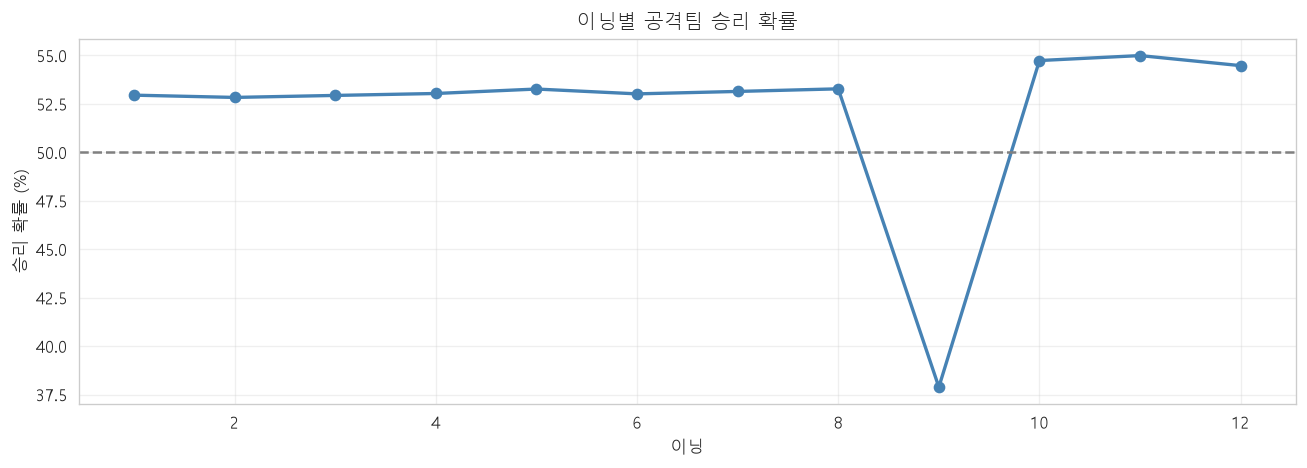

In [37]:
# 이닝별 공격팀 승리 확률
inn_win = (
    df[df['batting_team_win_label'].isin([0.0, 1.0])]
    .groupby('inning')['batting_team_win_label']
    .agg(['mean', 'count'])
)
inn_win = inn_win[inn_win['count'] >= 100]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(inn_win.index, inn_win['mean'] * 100, marker='o', color='steelblue', linewidth=2)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('이닝별 공격팀 승리 확률')
ax.set_xlabel('이닝')
ax.set_ylabel('승리 확률 (%)')
plt.tight_layout()
plt.show()

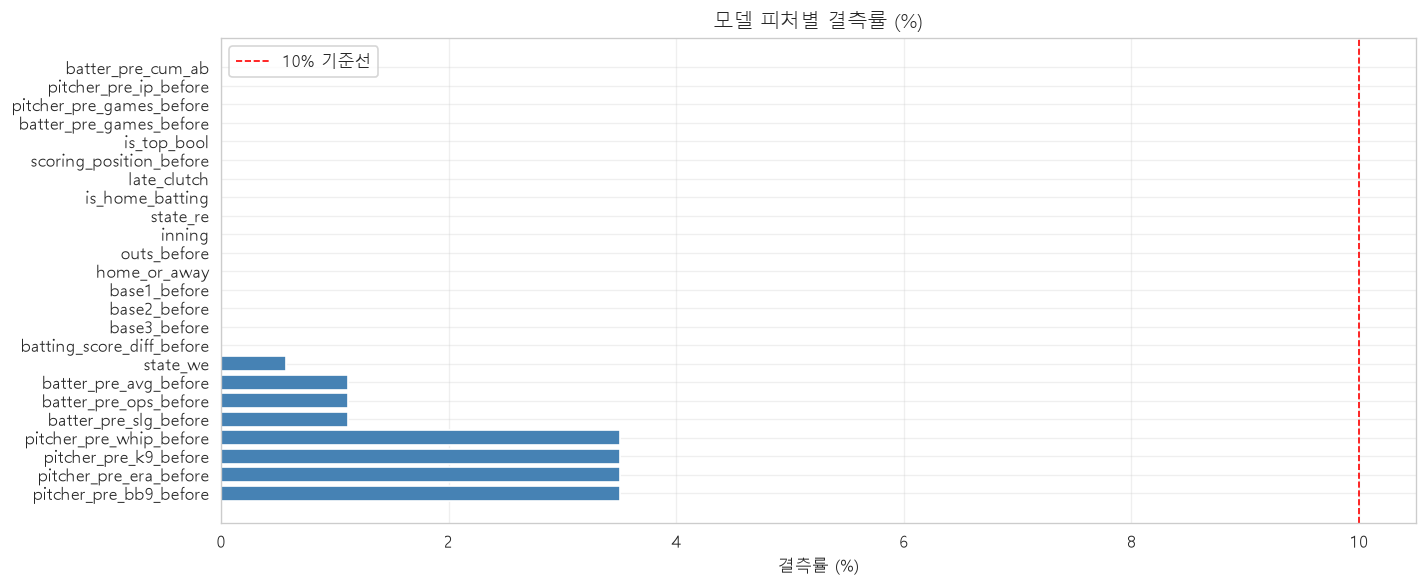

In [38]:
# 피처 결측률
feat_cols = [c for c in LOAD_COLS if c in df.columns
             and c not in ['game_id', 'season', 'batting_team_win_label']]
missing_rate = df[feat_cols].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['tomato' if v > 10 else 'steelblue' for v in missing_rate.values]
ax.barh(missing_rate.index, missing_rate.values, color=bar_colors)
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='10% 기준선')
ax.set_title('모델 피처별 결측률 (%)')
ax.set_xlabel('결측률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

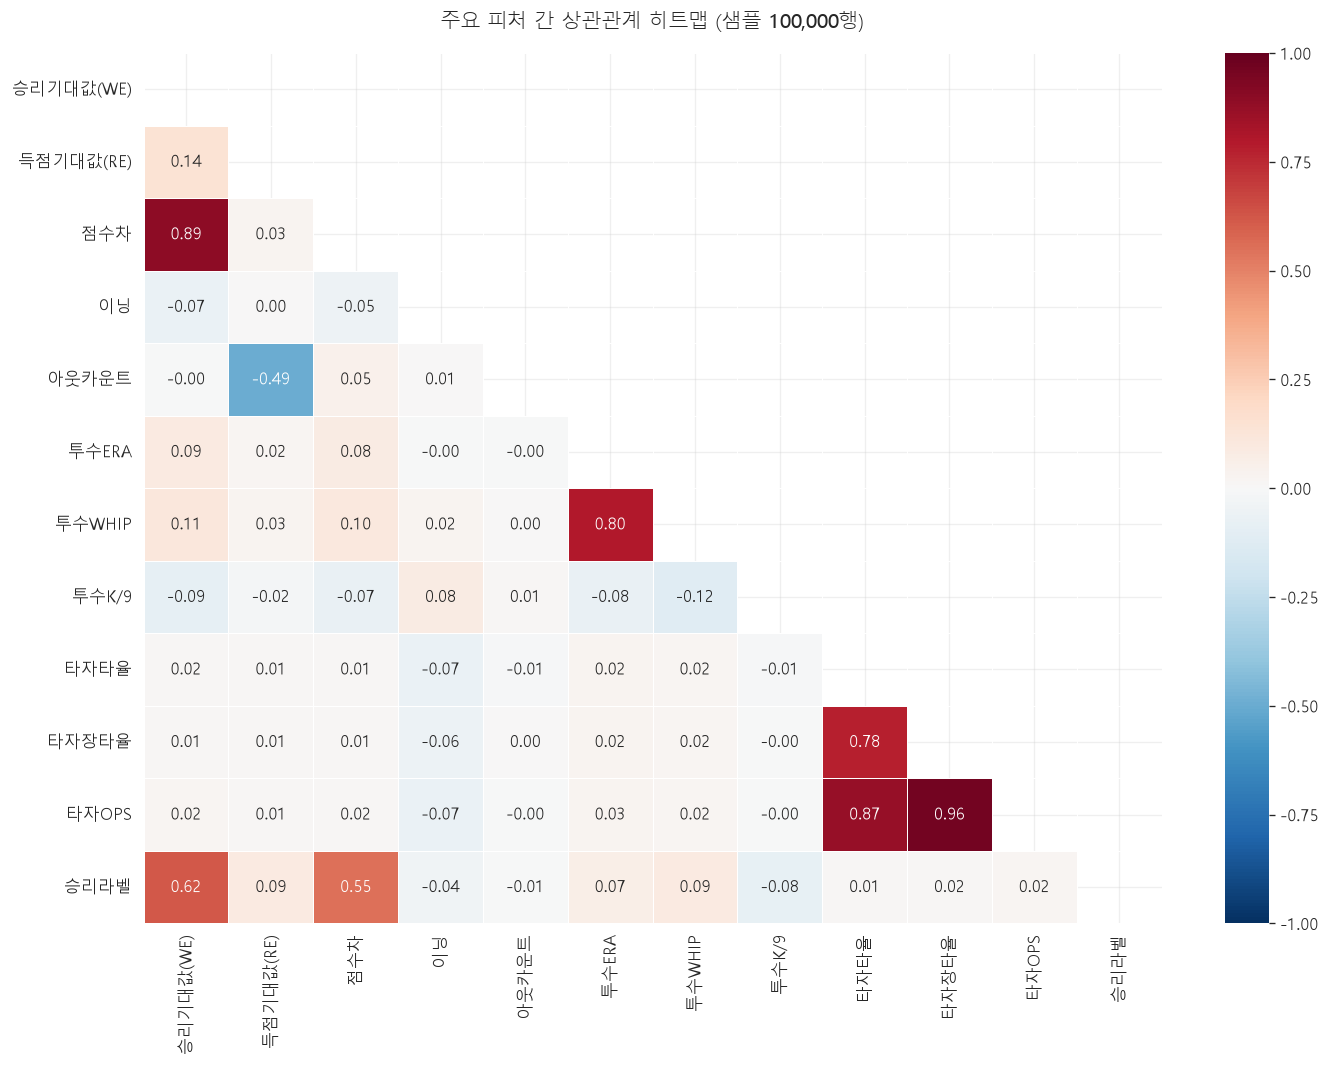

In [39]:
# 메모리 절약을 위해 10만 행 샘플로 상관관계 계산
corr_cols = [
    'state_we', 'state_re', 'batting_score_diff_before', 'inning', 'outs_before',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before', 'pitcher_pre_k9_before',
    'batter_pre_avg_before', 'batter_pre_slg_before', 'batter_pre_ops_before',
    'batting_team_win_label',
]
corr_cols = [c for c in corr_cols if c in df.columns]
sample_df = df[corr_cols].dropna().sample(n=min(100_000, len(df)), random_state=42)
corr = sample_df.corr()

kr_labels = {
    'state_we': '승리기대값(WE)', 'state_re': '득점기대값(RE)',
    'batting_score_diff_before': '점수차',
    'inning': '이닝', 'outs_before': '아웃카운트',
    'pitcher_pre_era_before': '투수ERA', 'pitcher_pre_whip_before': '투수WHIP',
    'pitcher_pre_k9_before': '투수K/9',
    'batter_pre_avg_before': '타자타율', 'batter_pre_slg_before': '타자장타율',
    'batter_pre_ops_before': '타자OPS', 'batting_team_win_label': '승리라벨',
}
corr.index   = [kr_labels.get(c, c) for c in corr.index]
corr.columns = [kr_labels.get(c, c) for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f'주요 피처 간 상관관계 히트맵 (샘플 {len(sample_df):,}행)', pad=15)
plt.tight_layout()
plt.show()

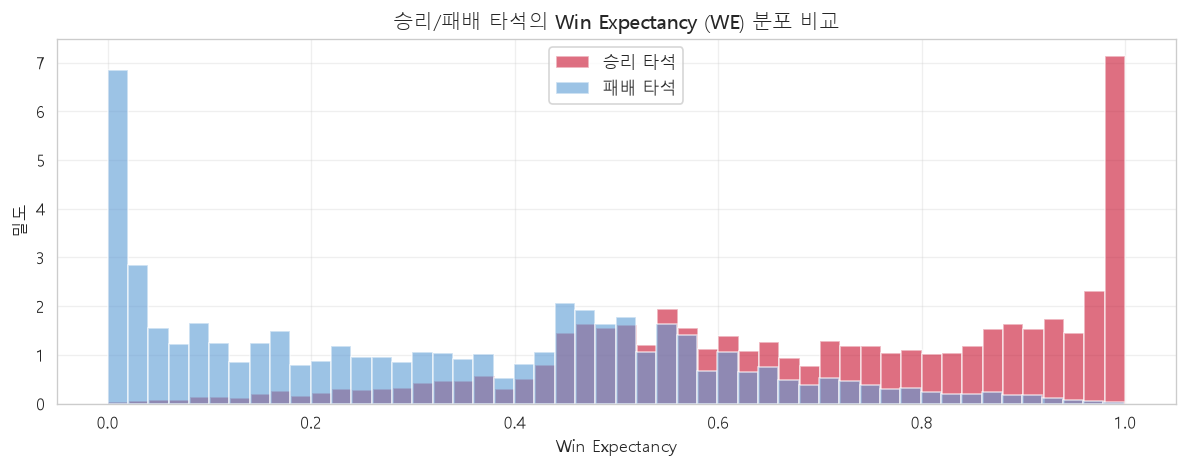

In [40]:
# 승/패별 Win Expectancy 분포 비교
win_we  = df[df['batting_team_win_label'] == 1.0]['state_we'].dropna()
lose_we = df[df['batting_team_win_label'] == 0.0]['state_we'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(win_we,  bins=50, alpha=0.6, color='#C8102E', label='승리 타석', density=True)
ax.hist(lose_we, bins=50, alpha=0.6, color='#5B9BD5', label='패배 타석', density=True)
ax.set_title('승리/패배 타석의 Win Expectancy (WE) 분포 비교')
ax.set_xlabel('Win Expectancy')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.show()

##### Win Expectancy(WE) 분포(각 WE 구간에 데이터가 얼마나 몰려있는지 상대적 농도)
1. x축 : WE, y축 : 밀도(해당 WE 국나에 관측치가 얼마나 몰려 있는가)
    - 승리 타석의 WE값이 얼마나 몰려있는지를 보여준다.
    - 즉, 최종적으로 이긴 타석과 진 타석이 어떤 WE 구간에 많이 분포했는지 비교
2. 승리 가능성이 낮은 상황에 있던 타석들(0.0~0.1 사이)은 실제로도 패배로 끝나는 경우가 많고, 이미 승리 가능성이 높았던 상황들(0.9~1.0 사이)은 실제로도 승리로 끝나는 경우가 많았다.

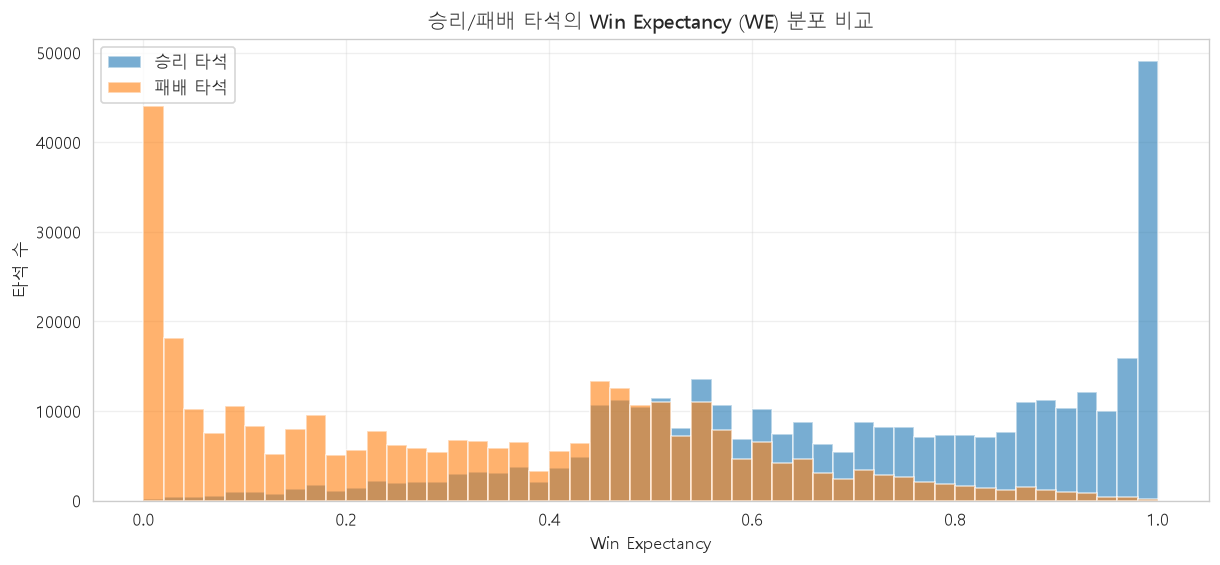

In [51]:
# 타석수로 봤을 때
plt.figure(figsize=(12, 5))

bins = np.linspace(0, 1, 51)

plt.hist(
    df[df["batting_team_win_label"] == 1]["state_we"],
    bins=bins,
    alpha=0.6,
    label="승리 타석"
)

plt.hist(
    df[df["batting_team_win_label"] == 0]["state_we"],
    bins=bins,
    alpha=0.6,
    label="패배 타석"
)

plt.xlabel("Win Expectancy")
plt.ylabel("타석 수")
plt.title("승리/패배 타석의 Win Expectancy (WE) 분포 비교")
plt.legend()
plt.show()

In [59]:
# 낮은 WE였는데 최종 승리한 타석 = 역전승 후보 상황
comeback_pa = df[
    (df["state_we"] <= 0.2) &
    (df["batting_team_win_label"] == 1)
].copy()

comeback_games_simple = (
    comeback_pa[["game_id"]]
    .drop_duplicates()
    .copy()
)

comeback_games_simple["game_date"] = pd.to_datetime(
    comeback_games_simple["game_id"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

comeback_games_simple["season"] = comeback_games_simple["game_date"].dt.year
comeback_games_simple["away_team_code"] = comeback_games_simple["game_id"].astype(str).str[8:10]
comeback_games_simple["home_team_code"] = comeback_games_simple["game_id"].astype(str).str[10:12]

comeback_games_simple = comeback_games_simple.sort_values(["game_date", "game_id"])

print("WE 0.2 이하였지만 최종 승리한 경기 수:", comeback_games_simple["game_id"].nunique())
display(comeback_games_simple.head(30))

WE 0.2 이하였지만 최종 승리한 경기 수: 1215


,game_id,game_date,season,away_team_code,home_team_code
1697,20150314LTWO0,2015-03-14,2015,LT,WO
2260,20150317NCOB0,2015-03-17,2015,NC,OB
2829,20150319SSNC0,2015-03-19,2015,SS,NC
3295,20150321HTKT0,2015-03-21,2015,HT,KT
3892,20150328HHWO0,2015-03-28,2015,HH,WO
3961,20150328KTLT0,2015-03-28,2015,KT,LT
4099,20150328NCOB0,2015-03-28,2015,NC,OB
4394,20150329LGHT0,2015-03-29,2015,LG,HT
5895,20150405SSLG0,2015-04-05,2015,SS,LG
6384,20150408LGHH0,2015-04-08,2015,LG,HH


In [60]:
# game_id별로 state_we가 가장 낮았던 타석의 index
idx = comeback_pa.groupby("game_id")["state_we"].idxmin()

# 경기별 대표 타석
comeback_games = comeback_pa.loc[idx].copy()

# 날짜/시즌/팀코드 생성
comeback_games["game_date"] = pd.to_datetime(
    comeback_games["game_id"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

comeback_games["season"] = comeback_games["game_date"].dt.year
comeback_games["away_team_code"] = comeback_games["game_id"].astype(str).str[8:10]
comeback_games["home_team_code"] = comeback_games["game_id"].astype(str).str[10:12]

# 해당 경기에서 WE 0.2 이하 + 최종 승리 조건을 만족한 타석 수
low_we_pa_count = (
    comeback_pa
    .groupby("game_id")
    .size()
    .rename("low_we_win_pa_count")
)

comeback_games = comeback_games.merge(
    low_we_pa_count,
    on="game_id",
    how="left"
)

view_cols = [
    "game_date",
    "season",
    "game_id",
    "away_team_code",
    "home_team_code",
    "inning",
    "state_we",
    "batting_score_diff_before",
    "outs_before",
    "low_we_win_pa_count",
]

display(
    comeback_games[view_cols]
    .sort_values(["game_date", "game_id"])
    .reset_index(drop=True)
)

,game_date,season,game_id,away_team_code,home_team_code,inning,state_we,batting_score_diff_before,outs_before,low_we_win_pa_count
0,2015-03-14,2015,20150314LTWO0,LT,WO,6.0,0.171946,-2.0,2.0,3
1,2015-03-17,2015,20150317NCOB0,NC,OB,2.0,0.192308,-2.0,2.0,1
2,2015-03-19,2015,20150319SSNC0,SS,NC,4.0,0.191781,-2.0,2.0,1
3,2015-03-21,2015,20150321HTKT0,HT,KT,9.0,0.010181,-3.0,1.0,14
4,2015-03-28,2015,20150328HHWO0,HH,WO,6.0,0.137097,-3.0,1.0,4
...,...,...,...,...,...,...,...,...,...,...
1210,2025-09-21,2025,20250921NCHT02025,NC,HT,7.0,0.134951,-2.0,1.0,40
1211,2025-09-26,2025,20250926SSLT02025,SS,LT,7.0,0.135697,-2.0,2.0,24
1212,2025-10-01,2025,20251001HHSK02025,HH,SK,9.0,0.005848,-3.0,2.0,96
1213,2025-10-01,2025,20251001KTHT02025,KT,HT,2.0,0.177500,-3.0,1.0,32


In [61]:
RESULT_COLS = [
    "batting_team_code",
    "fielding_team_code",
    "winner_team_code",
    "away_team_code",
    "home_team_code",
    "away_score",
    "home_score",
    "game_date",
]

LOAD_COLS = [
    "game_id",
    "inning", "home_or_away", "outs_before",
    "base1_before", "base2_before", "base3_before",
    "batting_score_diff_before",
    "state_we", "state_re",
    "late_clutch", "scoring_position_before",
    "is_top_bool", "is_home_batting",
    "pitcher_pre_era_before", "pitcher_pre_whip_before",
    "pitcher_pre_k9_before", "pitcher_pre_bb9_before",
    "pitcher_pre_ip_before", "pitcher_pre_games_before",
    "batter_pre_games_before", "batter_pre_cum_ab",
    "batter_pre_avg_before", "batter_pre_slg_before",
    "batter_pre_ops_before",
    "batting_team_win_label",

    # 경기 결과 확인용
    "batting_team_code",
    "fielding_team_code",
    "winner_team_code",
    "away_team_code",
    "home_team_code",
    "away_score",
    "home_score",
    "game_date",
]

STR_COLS = [
    "game_id",
    "batting_team_code",
    "fielding_team_code",
    "winner_team_code",
    "away_team_code",
    "home_team_code",
]

BOOL_COLS = [
    "late_clutch",
    "scoring_position_before",
    "is_top_bool",
    "is_home_batting",
]

df = pd.read_csv(
    DATA / "model_master_pa_extended_eligible.csv",
    usecols=lambda c: c in LOAD_COLS,
    dtype={c: "string" for c in STR_COLS},
    low_memory=False
)

df["season"] = pd.to_numeric(
    df["game_id"].astype(str).str[:4],
    errors="coerce"
)

df = df[df["season"].between(2015, 2025)].copy()
df["season"] = df["season"].astype("int16")

NUM_COLS = [
    c for c in LOAD_COLS
    if c not in STR_COLS + BOOL_COLS
]

for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

for col in BOOL_COLS:
    if col in df.columns:
        df[col] = (
            df[col]
            .map({
                True: 1, False: 0,
                "True": 1, "False": 0,
                "true": 1, "false": 0,
                "1": 1, "0": 0,
                1: 1, 0: 0,
            })
            .astype("float32")
        )

print(f"로드: {len(df):,}행 × {len(df.columns)}열")

comeback_pa = df[
    (df["state_we"] <= 0.2) &
    (df["batting_team_win_label"] == 1)
].copy()

print("WE 0.2 이하였지만 최종 승리한 타석:", len(comeback_pa))
print("해당 경기 수:", comeback_pa["game_id"].nunique())

idx = comeback_pa.groupby("game_id")["state_we"].idxmin()

comeback_games = comeback_pa.loc[idx].copy()

comeback_games["game_date"] = pd.to_datetime(
    comeback_games["game_id"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

# 이 낮은 WE를 겪은 공격팀이 실제 승리팀인지 다시 명시적으로 확인
comeback_games["is_actual_comeback_win"] = (
    comeback_games["batting_team_code"] == comeback_games["winner_team_code"]
).astype(int)

# 경기 스코어 표시용
comeback_games["score"] = (
    comeback_games["away_team_code"].astype(str)
    + " "
    + comeback_games["away_score"].astype("Int64").astype(str)
    + " : "
    + comeback_games["home_score"].astype("Int64").astype(str)
    + " "
    + comeback_games["home_team_code"].astype(str)
)

# 그 경기에서 조건을 만족한 타석 수
low_we_pa_count = (
    comeback_pa
    .groupby("game_id")
    .size()
    .rename("low_we_win_pa_count")
)

comeback_games = comeback_games.merge(
    low_we_pa_count,
    on="game_id",
    how="left"
)

view_cols = [
    "game_date",
    "season",
    "game_id",
    "away_team_code",
    "home_team_code",
    "score",
    "winner_team_code",
    "batting_team_code",
    "fielding_team_code",
    "is_actual_comeback_win",
    "inning",
    "outs_before",
    "state_we",
    "batting_score_diff_before",
    "low_we_win_pa_count",
]

display(
    comeback_games[view_cols]
    .sort_values(["game_date", "game_id"])
    .reset_index(drop=True)
)

로드: 687,954행 × 35열
WE 0.2 이하였지만 최종 승리한 타석: 8503
해당 경기 수: 1215


,game_date,season,game_id,away_team_code,home_team_code,score,winner_team_code,batting_team_code,fielding_team_code,is_actual_comeback_win,inning,outs_before,state_we,batting_score_diff_before,low_we_win_pa_count
0,2015-03-14,2015,20150314LTWO0,LT,WO,LT 5 : 3 WO,LT,LT,WO,1,6.0,2.0,0.171946,-2.0,3
1,2015-03-17,2015,20150317NCOB0,NC,OB,NC 5 : 4 OB,NC,NC,OB,1,2.0,2.0,0.192308,-2.0,1
2,2015-03-19,2015,20150319SSNC0,SS,NC,SS 6 : 5 NC,SS,SS,NC,1,4.0,2.0,0.191781,-2.0,1
3,2015-03-21,2015,20150321HTKT0,HT,KT,HT 4 : 3 KT,HT,HT,KT,1,9.0,1.0,0.010181,-3.0,14
4,2015-03-28,2015,20150328HHWO0,HH,WO,HH 4 : 5 WO,WO,WO,HH,1,6.0,1.0,0.137097,-3.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,2025-09-21,2025,20250921NCHT02025,NC,HT,NC 7 : 6 HT,NC,NC,HT,1,7.0,1.0,0.134951,-2.0,40
1211,2025-09-26,2025,20250926SSLT02025,SS,LT,SS 9 : 10 LT,LT,LT,SS,1,7.0,2.0,0.135697,-2.0,24
1212,2025-10-01,2025,20251001HHSK02025,HH,SK,HH 5 : 6 SK,SK,SK,HH,1,9.0,2.0,0.005848,-3.0,96
1213,2025-10-01,2025,20251001KTHT02025,KT,HT,KT 9 : 3 HT,KT,KT,HT,1,2.0,1.0,0.177500,-3.0,32


##### 역전승 후보(롯데만)

In [69]:
lotte_comeback_games = comeback_games[ (comeback_games["batting_team_code"] == "LT") &
                                      (comeback_games["is_actual_comeback_win"] == 1)
                                        ].copy()

lotte_late_comeback_games = comeback_games[
    (comeback_games["batting_team_code"] == "LT") &
    (comeback_games["is_actual_comeback_win"] == 1) &
    (comeback_games["inning"] >= 7)
].copy()

display(
    lotte_late_comeback_games[view_cols]
    .sort_values(["state_we", "game_date", "game_id"])
    .reset_index(drop=True)
)

print("롯데 역전승 후보 경기 수:", len(lotte_comeback_games))
print("롯데 7회 이후 역전승 후보 경기 수:", len(lotte_late_comeback_games))

,game_date,season,game_id,away_team_code,home_team_code,score,winner_team_code,batting_team_code,fielding_team_code,is_actual_comeback_win,inning,outs_before,state_we,batting_score_diff_before,low_we_win_pa_count
0,2019-05-12,2019,20190512LTSS02019,LT,SS,LT 10 : 9 SS,LT,LT,SS,1,7.0,0.0,0.006765,-6.0,26
1,2021-06-06,2021,20210606LTKT02021,LT,KT,LT 8 : 7 KT,LT,LT,KT,1,9.0,0.0,0.008235,-5.0,31
2,2022-09-13,2022,20220913SKLT02022,SK,LT,SK 8 : 9 LT,LT,LT,SK,1,8.0,2.0,0.010684,-4.0,13
3,2022-03-15,2022,20220315HHLT02022,HH,LT,HH 12 : 13 LT,LT,LT,HH,1,9.0,0.0,0.012334,-4.0,10
4,2016-06-30,2016,20160630SSLT02016,SS,LT,SS 6 : 7 LT,LT,LT,SS,1,9.0,2.0,0.014249,-2.0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,2025-08-28,2025,20250828KTLT02025,KT,LT,KT 2 : 3 LT,LT,LT,KT,1,10.0,0.0,0.174650,-1.0,1
65,2018-03-16,2018,20180316OBLT02018,OB,LT,OB 5 : 9 LT,LT,LT,OB,1,7.0,1.0,0.175875,-2.0,2
66,2024-08-01,2024,20240801LTSK02024,LT,SK,LT 4 : 2 SK,LT,LT,SK,1,7.0,0.0,0.177337,-2.0,1
67,2024-04-19,2024,20240419KTLT02024,KT,LT,KT 3 : 4 LT,LT,LT,KT,1,7.0,1.0,0.178571,-2.0,1


롯데 역전승 후보 경기 수: 133
롯데 7회 이후 역전승 후보 경기 수: 69


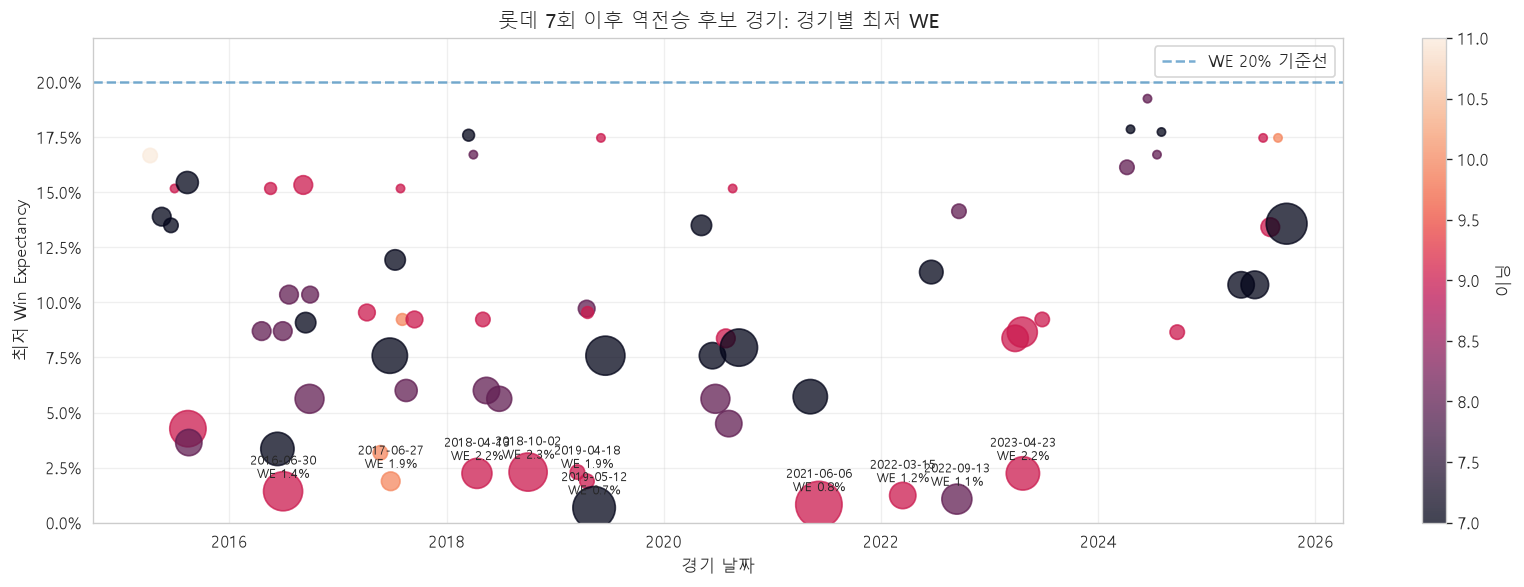

In [71]:
import matplotlib.ticker as mticker

plot_df = lotte_late_comeback_games.copy()

plot_df["game_date"] = pd.to_datetime(plot_df["game_date"], errors="coerce")
plot_df["state_we"] = pd.to_numeric(plot_df["state_we"], errors="coerce")
plot_df["inning"] = pd.to_numeric(plot_df["inning"], errors="coerce")
plot_df["low_we_win_pa_count"] = pd.to_numeric(
    plot_df["low_we_win_pa_count"],
    errors="coerce"
).fillna(1)

plot_df = plot_df.sort_values("game_date")

top10 = plot_df.nsmallest(10, "state_we")

plt.figure(figsize=(14, 5))

scatter = plt.scatter(
    plot_df["game_date"],
    plot_df["state_we"],
    s=plot_df["low_we_win_pa_count"] * 25,
    c=plot_df["inning"],
    alpha=0.75
)

for _, row in top10.iterrows():
    label = f'{row["game_date"].strftime("%Y-%m-%d")}\nWE {row["state_we"]:.1%}'

    plt.annotate(
        label,
        xy=(row["game_date"], row["state_we"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.axhline(0.2, linestyle="--", alpha=0.6, label="WE 20% 기준선")

plt.title("롯데 7회 이후 역전승 후보 경기: 경기별 최저 WE")
plt.xlabel("경기 날짜")
plt.ylabel("최저 Win Expectancy")

plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.ylim(0, 0.22)

cbar = plt.colorbar(scatter)
cbar.set_label("이닝")

plt.legend()
plt.tight_layout()
plt.show()

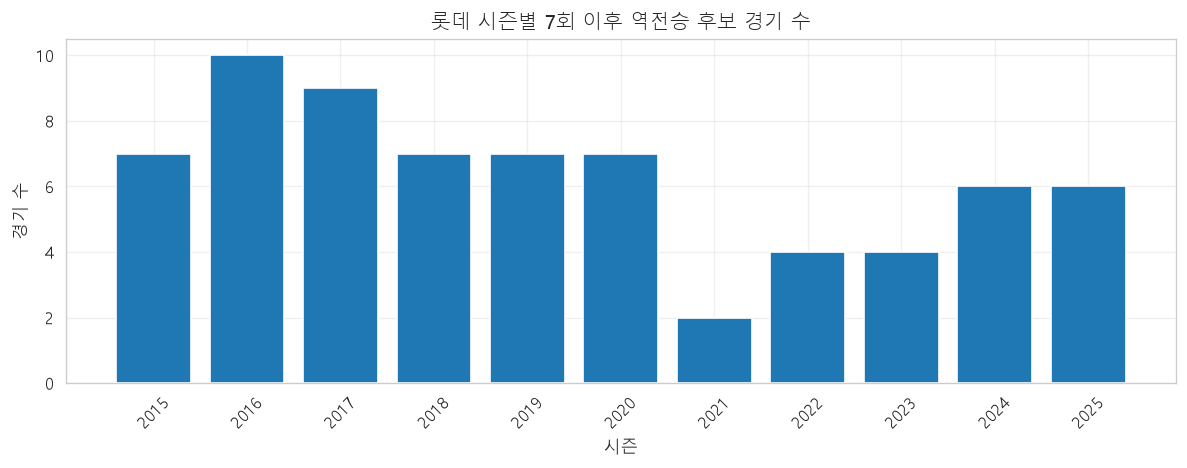

In [72]:
season_cnt = (
    lotte_late_comeback_games
    .groupby("season")["game_id"]
    .nunique()
    .reset_index(name="late_comeback_game_count")
)

plt.figure(figsize=(10, 4))

plt.bar(
    season_cnt["season"],
    season_cnt["late_comeback_game_count"]
)

plt.title("롯데 시즌별 7회 이후 역전승 후보 경기 수")
plt.xlabel("시즌")
plt.ylabel("경기 수")
plt.xticks(season_cnt["season"], rotation=45)

plt.tight_layout()
plt.show()

In [73]:
top10_table = (
    lotte_late_comeback_games
    .sort_values("state_we")
    .head(10)
    [view_cols]
    .reset_index(drop=True)
)

display(top10_table)

,game_date,season,game_id,away_team_code,home_team_code,score,winner_team_code,batting_team_code,fielding_team_code,is_actual_comeback_win,inning,outs_before,state_we,batting_score_diff_before,low_we_win_pa_count
0,2019-05-12,2019,20190512LTSS02019,LT,SS,LT 10 : 9 SS,LT,LT,SS,1,7.0,0.0,0.006765,-6.0,26
1,2021-06-06,2021,20210606LTKT02021,LT,KT,LT 8 : 7 KT,LT,LT,KT,1,9.0,0.0,0.008235,-5.0,31
2,2022-09-13,2022,20220913SKLT02022,SK,LT,SK 8 : 9 LT,LT,LT,SK,1,8.0,2.0,0.010684,-4.0,13
3,2022-03-15,2022,20220315HHLT02022,HH,LT,HH 12 : 13 LT,LT,LT,HH,1,9.0,0.0,0.012334,-4.0,10
4,2016-06-30,2016,20160630SSLT02016,SS,LT,SS 6 : 7 LT,LT,LT,SS,1,9.0,2.0,0.014249,-2.0,22
5,2017-06-27,2017,20170627LGLT02017,LG,LT,LG 10 : 11 LT,LT,LT,LG,1,10.0,0.0,0.018797,-5.0,5
6,2019-04-18,2019,20190418HTLT02019,HT,LT,HT 9 : 10 LT,LT,LT,HT,1,9.0,0.0,0.018797,-5.0,3
7,2018-04-13,2018,20180413LTHT02018,LT,HT,LT 8 : 4 HT,LT,LT,HT,1,9.0,0.0,0.022364,-3.0,13
8,2023-04-23,2023,20230423LTNC02023,LT,NC,LT 5 : 3 NC,LT,LT,NC,1,9.0,0.0,0.022364,-3.0,16
9,2019-03-17,2019,20190317LTHH02019,LT,HH,LT 8 : 6 HH,LT,LT,HH,1,9.0,1.0,0.022965,-2.0,3


In [74]:
lotte_pa = df[
    (df["batting_team_code"] == "LT") |
    (df["fielding_team_code"] == "LT")
].copy()

lotte_pa["inning"] = pd.to_numeric(lotte_pa["inning"], errors="coerce")
lotte_pa["state_we"] = pd.to_numeric(lotte_pa["state_we"], errors="coerce")

# 롯데 기준 승리확률
lotte_pa["lotte_we"] = np.where(
    lotte_pa["batting_team_code"] == "LT",
    lotte_pa["state_we"],
    1 - lotte_pa["state_we"]
)

# 롯데 최종 승리 여부
lotte_pa["lotte_win"] = (lotte_pa["winner_team_code"] == "LT").astype(int)

lotte_pa["game_date"] = pd.to_datetime(
    lotte_pa["game_id"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

lotte_pa["season"] = lotte_pa["game_date"].dt.year

lotte_late_comeback_pa = lotte_pa[
    (lotte_pa["inning"] >= 7) &
    (lotte_pa["lotte_we"] <= 0.2) &
    (lotte_pa["lotte_win"] == 1)
].copy()

idx_comeback = lotte_late_comeback_pa.groupby("game_id")["lotte_we"].idxmin()

lotte_late_comeback_games = lotte_late_comeback_pa.loc[idx_comeback].copy()
lotte_late_comeback_games["case_type"] = "역전승"

lotte_late_collapse_pa = lotte_pa[
    (lotte_pa["inning"] >= 7) &
    (lotte_pa["lotte_we"] >= 0.8) &
    (lotte_pa["lotte_win"] == 0)
].copy()

idx_collapse = lotte_late_collapse_pa.groupby("game_id")["lotte_we"].idxmax()

lotte_late_collapse_games = lotte_late_collapse_pa.loc[idx_collapse].copy()
lotte_late_collapse_games["case_type"] = "역전패"

print("롯데 7회 이후 역전승 후보 경기 수:", lotte_late_comeback_games["game_id"].nunique())
print("롯데 7회 이후 역전패 후보 경기 수:", lotte_late_collapse_games["game_id"].nunique())

롯데 7회 이후 역전승 후보 경기 수: 98
롯데 7회 이후 역전패 후보 경기 수: 114


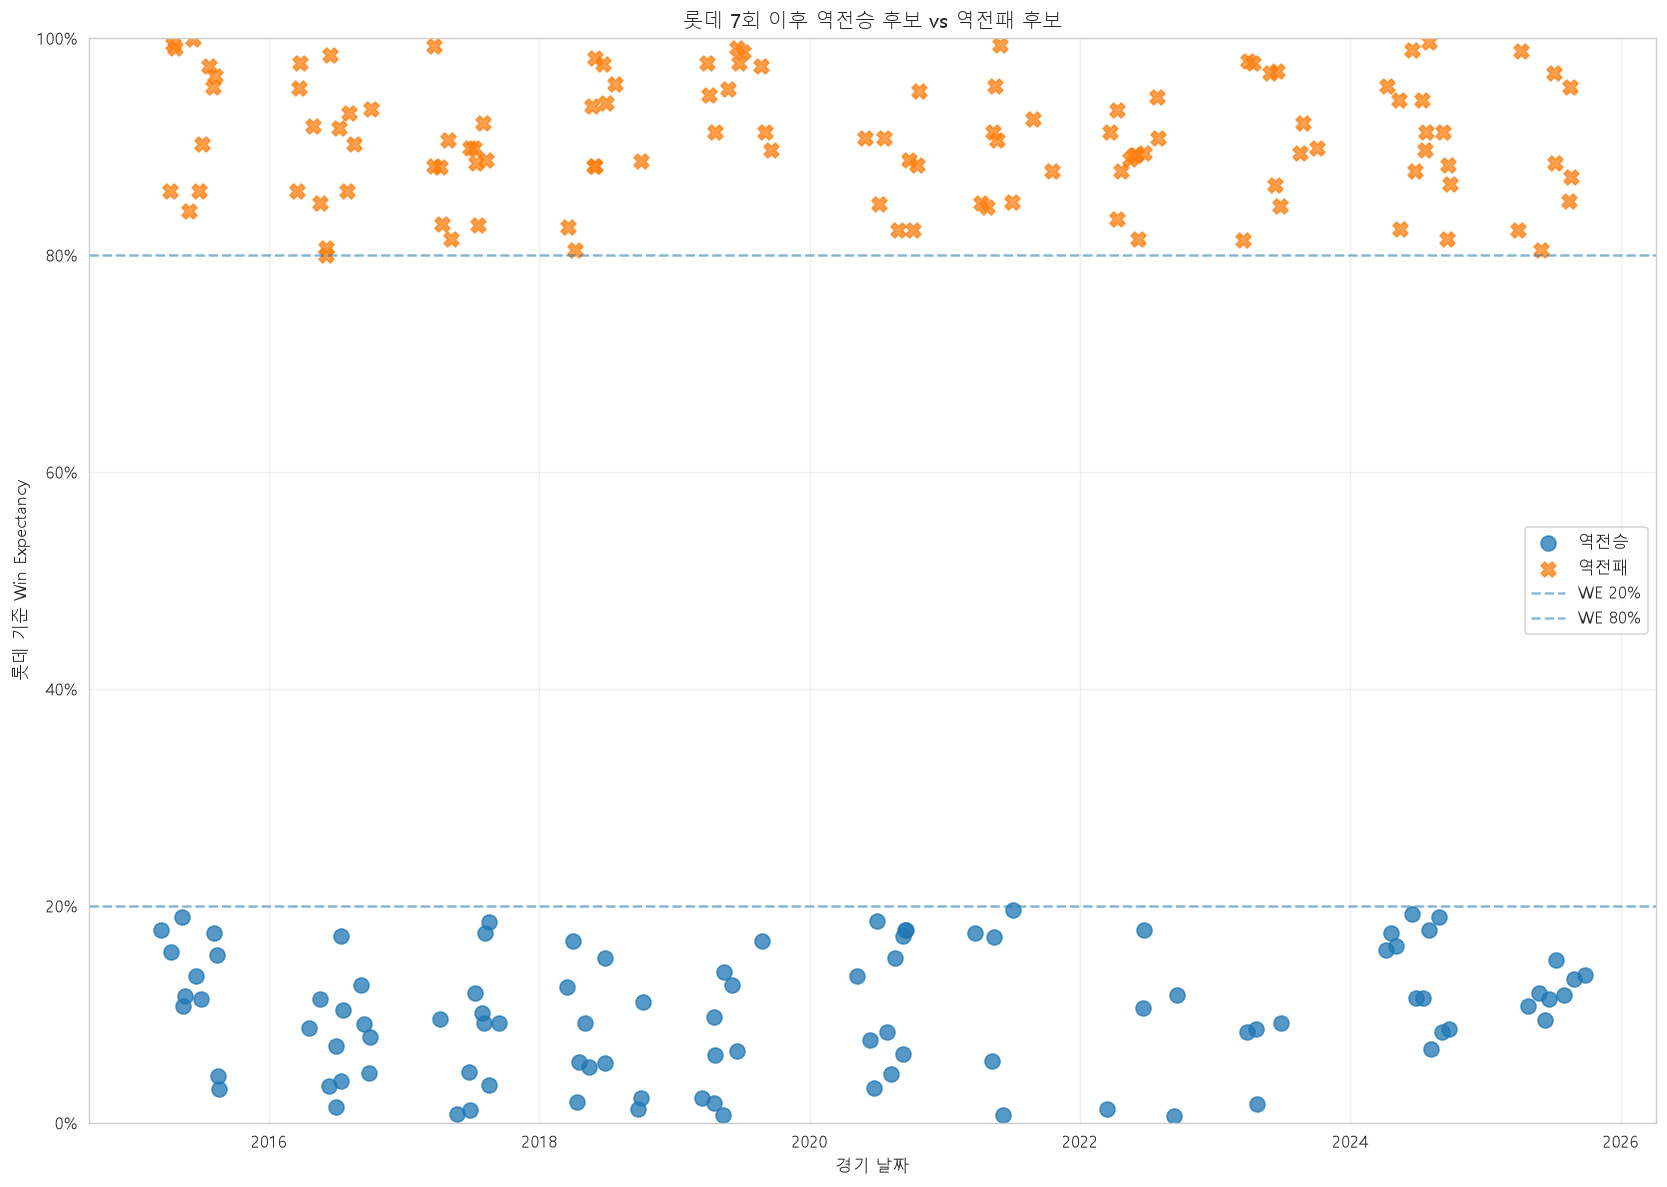

In [76]:
compare_games = pd.concat(
    [lotte_late_comeback_games, lotte_late_collapse_games],
    ignore_index=True
)

compare_games = compare_games.sort_values("game_date")

plt.figure(figsize=(14, 10))

for case_type, marker in [("역전승", "o"), ("역전패", "X")]:
    sub = compare_games[compare_games["case_type"] == case_type]

    plt.scatter(
        sub["game_date"],
        sub["lotte_we"],
        s=80,
        alpha=0.75,
        label=case_type,
        marker=marker
    )

plt.axhline(0.2, linestyle="--", alpha=0.5, label="WE 20%")
plt.axhline(0.8, linestyle="--", alpha=0.5, label="WE 80%")

plt.title("롯데 7회 이후 역전승 후보 vs 역전패 후보")
plt.xlabel("경기 날짜")
plt.ylabel("롯데 기준 Win Expectancy")

plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

case_type,역전승,역전패
season,,
2015,11,10
2016,12,13
2017,11,12
2018,11,10
2019,9,10
2020,11,8
2021,5,9
2022,5,11
2023,4,10


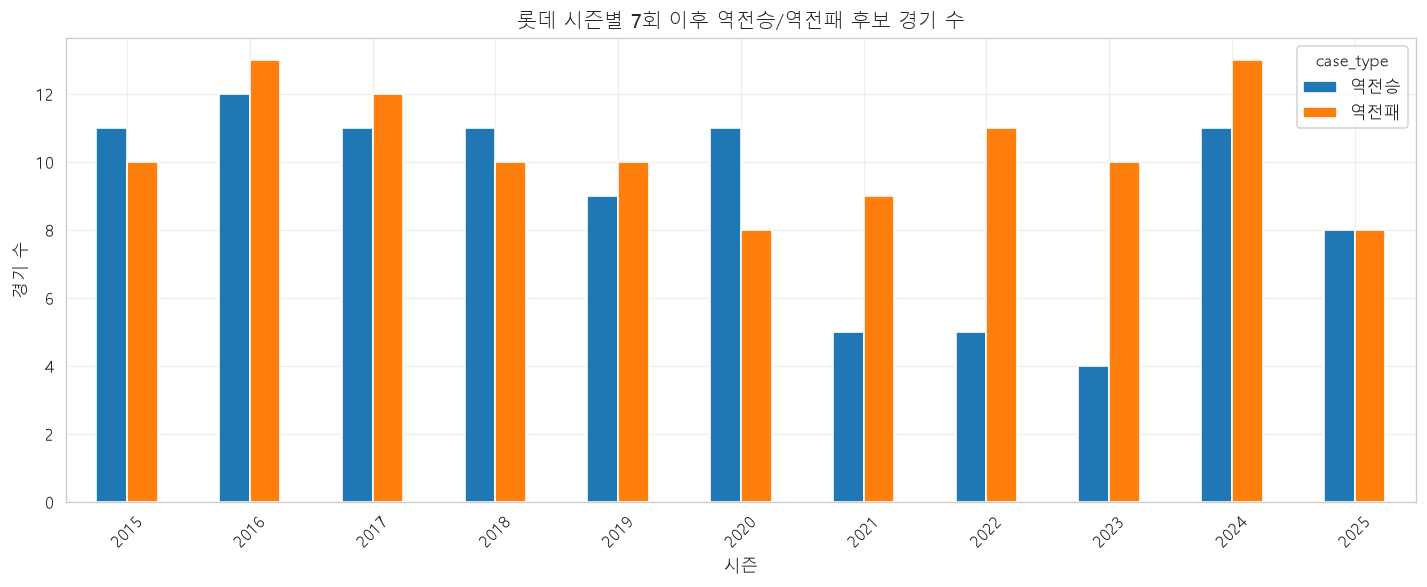

In [77]:
season_compare = (
    compare_games
    .groupby(["season", "case_type"])["game_id"]
    .nunique()
    .reset_index(name="game_count")
)

pivot_compare = season_compare.pivot(
    index="season",
    columns="case_type",
    values="game_count"
).fillna(0)

display(pivot_compare)

pivot_compare.plot(kind="bar", figsize=(12, 5))

plt.title("롯데 시즌별 7회 이후 역전승/역전패 후보 경기 수")
plt.xlabel("시즌")
plt.ylabel("경기 수")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- 2021~2023은 역전패 후보가 역전승 후보보다 거의 2배 수준
- 7회 이후 한때 롯데의 승리확률이 높았던 경기를 끝까지 닫지 못한 경우가 많았다.

##### 팀별 역전승/역전패 비교
---

In [79]:
team_pa_bat = df.copy()
team_pa_bat["team_code"] = team_pa_bat["batting_team_code"]
team_pa_bat["team_we"] = team_pa_bat["state_we"]

team_pa_field = df.copy()
team_pa_field["team_code"] = team_pa_field["fielding_team_code"]
team_pa_field["team_we"] = 1 - team_pa_field["state_we"]

team_pa = pd.concat([team_pa_bat, team_pa_field], ignore_index=True)

team_pa["inning"] = pd.to_numeric(team_pa["inning"], errors="coerce")
team_pa["team_we"] = pd.to_numeric(team_pa["team_we"], errors="coerce")

team_pa["game_date"] = pd.to_datetime(
    team_pa["game_id"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

team_pa["season"] = team_pa["game_date"].dt.year
team_pa["team_win"] = (team_pa["team_code"] == team_pa["winner_team_code"]).astype(int)

team_games = (
    team_pa
    .drop_duplicates(["game_id", "team_code"])
    .copy()
)

team_win_summary = (
    team_games
    .groupby("team_code")
    .agg(
        games=("game_id", "nunique"),
        wins=("team_win", "sum")
    )
    .reset_index()
)

team_win_summary["win_rate"] = team_win_summary["wins"] / team_win_summary["games"]

display(
    team_win_summary
    .sort_values("wins", ascending=False)
    .reset_index(drop=True)
)

,team_code,games,wins,win_rate
0,OB,1681,897,0.533611
1,LG,1689,891,0.527531
2,SK,1682,842,0.500595
3,NC,1688,842,0.498815
4,HT,1689,832,0.492599
5,WO,1689,817,0.483718
6,KT,1685,795,0.471810
7,SS,1682,794,0.472057
8,LT,1686,769,0.456109
9,HH,1681,729,0.433670


In [80]:
top_win_team = (
    team_win_summary
    .sort_values("wins", ascending=False)
    .iloc[0]["team_code"]
)

print("2015~2025 최다승 팀:", top_win_team)

compare_teams = ["LT", top_win_team]
print(compare_teams)

late_pa = team_pa[team_pa["inning"] >= 7].copy()

team_late_games = (
    late_pa
    .groupby(["season", "game_id", "team_code"], as_index=False)
    .agg(
        min_we=("team_we", "min"),
        max_we=("team_we", "max"),
        team_win=("team_win", "max"),
        game_date=("game_date", "first")
    )
)

team_late_games["low_we_candidate"] = team_late_games["min_we"] <= 0.2
team_late_games["high_we_candidate"] = team_late_games["max_we"] >= 0.8

team_late_games["comeback_win"] = (
    team_late_games["low_we_candidate"] &
    (team_late_games["team_win"] == 1)
)

team_late_games["collapse_loss"] = (
    team_late_games["high_we_candidate"] &
    (team_late_games["team_win"] == 0)
)

team_late_summary = (
    team_late_games
    .groupby(["season", "team_code"], as_index=False)
    .agg(
        late_games=("game_id", "nunique"),
        low_we_games=("low_we_candidate", "sum"),
        comeback_wins=("comeback_win", "sum"),
        high_we_games=("high_we_candidate", "sum"),
        collapse_losses=("collapse_loss", "sum")
    )
)

team_late_summary["comeback_rate"] = (
    team_late_summary["comeback_wins"] / team_late_summary["low_we_games"]
)

team_late_summary["collapse_rate"] = (
    team_late_summary["collapse_losses"] / team_late_summary["high_we_games"]
)

team_late_summary["net_comeback"] = (
    team_late_summary["comeback_wins"] - team_late_summary["collapse_losses"]
)

display(team_late_summary.head())

2015~2025 최다승 팀: OB
['LT', 'OB']


,season,team_code,late_games,low_we_games,comeback_wins,high_we_games,collapse_losses,comeback_rate,collapse_rate,net_comeback
0,2015,HH,155,85,7,77,9,0.082353,0.116883,-2
1,2015,HT,156,90,10,76,9,0.111111,0.118421,1
2,2015,KT,153,101,4,61,9,0.039604,0.147541,-5
3,2015,LG,155,85,6,72,8,0.070588,0.111111,-2
4,2015,LT,156,86,11,81,10,0.127907,0.123457,1


In [81]:
compare_summary = team_late_summary[
    team_late_summary["team_code"].isin(compare_teams)
].copy()

display(
    compare_summary
    .sort_values(["season", "team_code"])
    .reset_index(drop=True)
)

,season,team_code,late_games,low_we_games,comeback_wins,high_we_games,collapse_losses,comeback_rate,collapse_rate,net_comeback
0,2015,LT,156,86,11,81,10,0.127907,0.123457,1
1,2015,OB,153,77,12,90,10,0.155844,0.111111,2
2,2016,LT,158,99,12,78,13,0.121212,0.166667,-1
3,2016,OB,160,65,9,111,13,0.138462,0.117117,-4
4,2017,LT,155,77,11,95,12,0.142857,0.126316,-1
5,2017,OB,154,77,15,95,8,0.194805,0.084211,7
6,2018,LT,149,88,11,78,10,0.125000,0.128205,1
7,2018,OB,150,64,10,104,11,0.156250,0.105769,-1
8,2019,LT,150,103,9,61,10,0.087379,0.163934,-1
9,2019,OB,150,62,6,98,8,0.096774,0.081633,-2


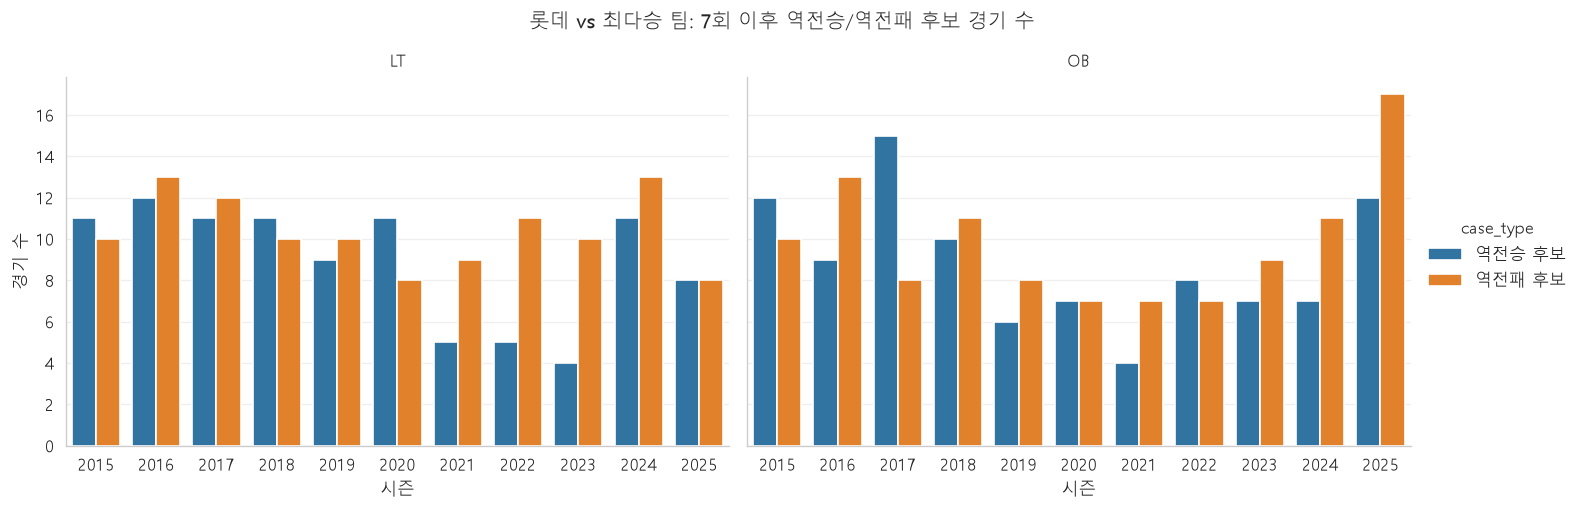

In [82]:
plot_counts = compare_summary.melt(
    id_vars=["season", "team_code"],
    value_vars=["comeback_wins", "collapse_losses"],
    var_name="case_type",
    value_name="game_count"
)

plot_counts["case_type"] = plot_counts["case_type"].map({
    "comeback_wins": "역전승 후보",
    "collapse_losses": "역전패 후보"
})

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=plot_counts,
    x="season",
    y="game_count",
    hue="case_type",
    col="team_code",
    kind="bar",
    height=4,
    aspect=1.5,
    sharey=True
)

g.set_axis_labels("시즌", "경기 수")
g.set_titles("{col_name}")
g.fig.suptitle("롯데 vs 최다승 팀: 7회 이후 역전승/역전패 후보 경기 수", y=1.05)

plt.show()

In [83]:
compare_rate_view = compare_summary[
    ["season", "team_code",
     "low_we_games", "comeback_wins", "comeback_rate",
     "high_we_games", "collapse_losses", "collapse_rate",
     "net_comeback"]
].copy()

compare_rate_view["comeback_rate"] = compare_rate_view["comeback_rate"].round(3)
compare_rate_view["collapse_rate"] = compare_rate_view["collapse_rate"].round(3)

display(
    compare_rate_view
    .sort_values(["season", "team_code"])
    .reset_index(drop=True)
)

,season,team_code,low_we_games,comeback_wins,comeback_rate,high_we_games,collapse_losses,collapse_rate,net_comeback
0,2015,LT,86,11,0.128,81,10,0.123,1
1,2015,OB,77,12,0.156,90,10,0.111,2
2,2016,LT,99,12,0.121,78,13,0.167,-1
3,2016,OB,65,9,0.138,111,13,0.117,-4
4,2017,LT,77,11,0.143,95,12,0.126,-1
5,2017,OB,77,15,0.195,95,8,0.084,7
6,2018,LT,88,11,0.125,78,10,0.128,1
7,2018,OB,64,10,0.156,104,11,0.106,-1
8,2019,LT,103,9,0.087,61,10,0.164,-1
9,2019,OB,62,6,0.097,98,8,0.082,-2


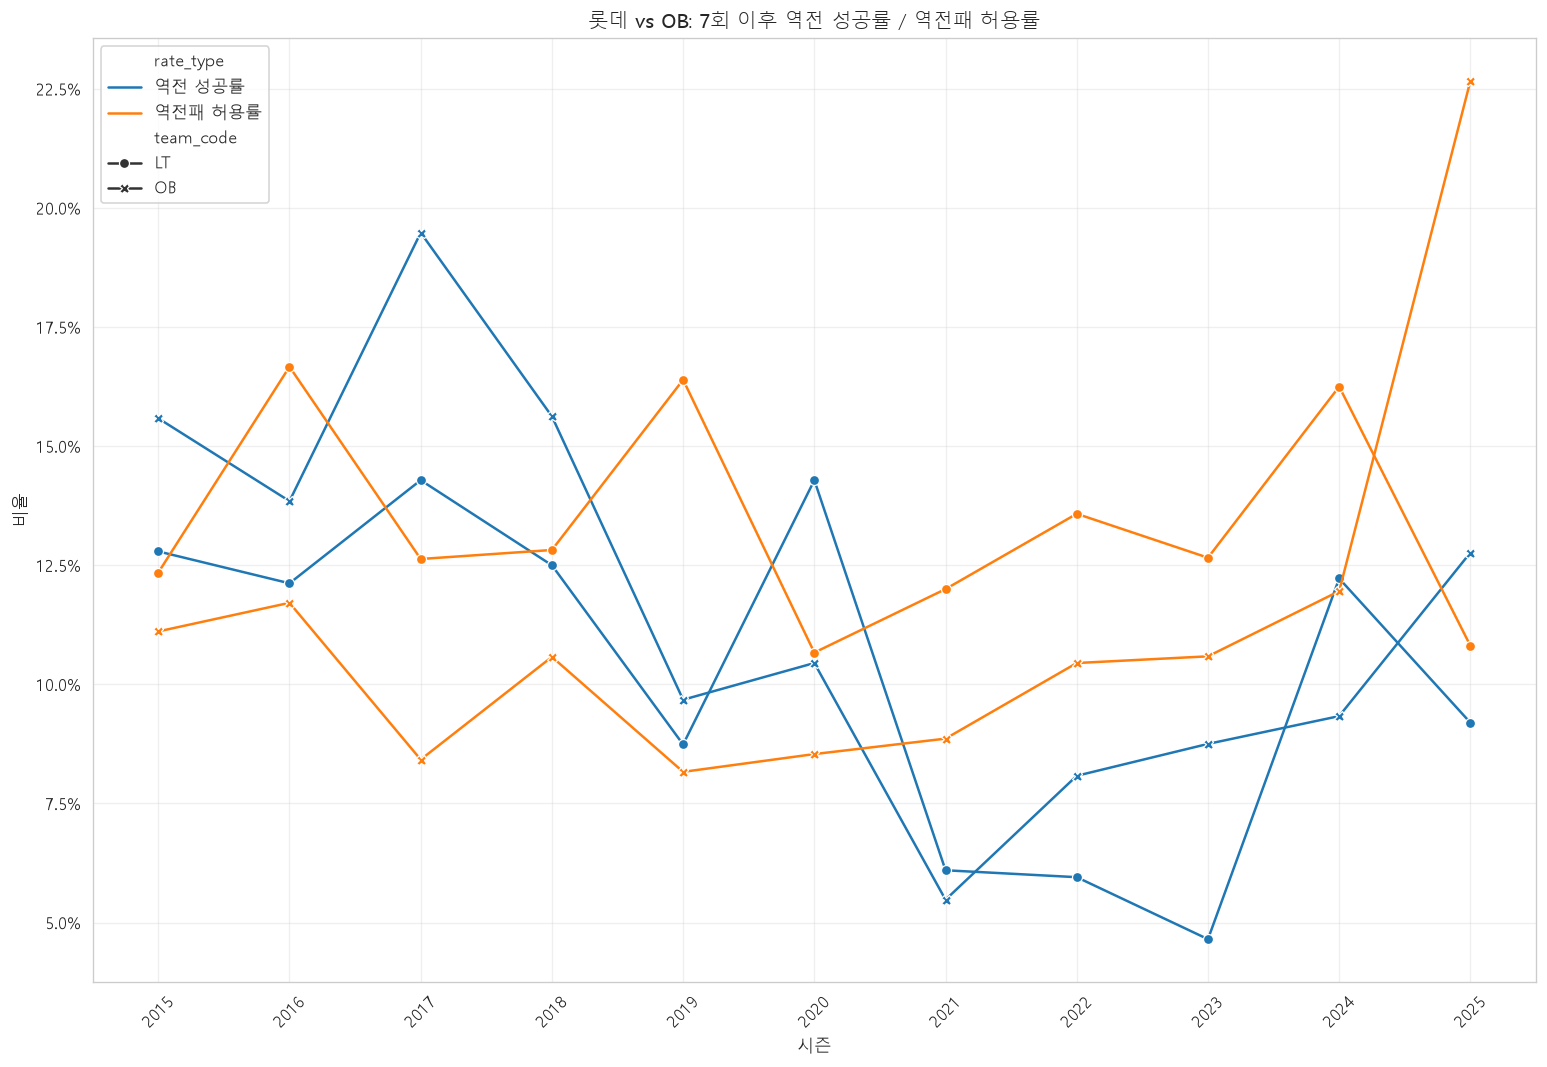

In [ ]:
plot_rates = compare_summary.melt(
    id_vars=["season", "team_code"],
    value_vars=["comeback_rate", "collapse_rate"],
    var_name="rate_type",
    value_name="rate"
)

plot_rates["rate_type"] = plot_rates["rate_type"].map({
    "comeback_rate": "역전 성공률",
    "collapse_rate": "역전패 허용률"
})

plt.figure(figsize=(13, 9))

sns.lineplot(
    data=plot_rates,
    x="season",
    y="rate",
    hue="rate_type",
    style="team_code",
    markers=True,
    dashes=False
)

plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.title("롯데 vs OB: 7회 이후 역전 성공률 / 역전패 허용률")
plt.xlabel("시즌")
plt.ylabel("비율")
plt.xticks(sorted(plot_rates["season"].dropna().unique()), rotation=45)

plt.tight_layout()
plt.show()

In [85]:
compare_summary["volatility_games"] = (
    compare_summary["comeback_wins"] + compare_summary["collapse_losses"]
)

compare_summary["volatility_rate"] = (
    compare_summary["volatility_games"] / compare_summary["late_games"]
)

display(
    compare_summary[
        ["season", "team_code", "late_games",
         "comeback_wins", "collapse_losses",
         "volatility_games", "volatility_rate"]
    ]
    .sort_values(["season", "team_code"])
    .reset_index(drop=True)
)

,season,team_code,late_games,comeback_wins,collapse_losses,volatility_games,volatility_rate
0,2015,LT,156,11,10,21,0.134615
1,2015,OB,153,12,10,22,0.143791
2,2016,LT,158,12,13,25,0.158228
3,2016,OB,160,9,13,22,0.137500
4,2017,LT,155,11,12,23,0.148387
5,2017,OB,154,15,8,23,0.149351
6,2018,LT,149,11,10,21,0.140940
7,2018,OB,150,10,11,21,0.140000
8,2019,LT,150,9,10,19,0.126667
9,2019,OB,150,6,8,14,0.093333


In [87]:
period_df = compare_summary.copy()

period_df["period"] = pd.cut(
    period_df["season"],
    bins=[2014, 2019, 2021, 2024, 2025],
    labels=[
        "2015-2019 코로나 이전",
        "2020-2021 코로나/일정 교란",
        "2022-2024 전환기",
        "2025"
    ]
)

period_summary = (
    period_df
    .groupby(["team_code", "period"], observed=True)
    .agg(
        seasons=("season", "nunique"),
        low_we_games=("low_we_games", "sum"),
        comeback_wins=("comeback_wins", "sum"),
        high_we_games=("high_we_games", "sum"),
        collapse_losses=("collapse_losses", "sum"),
    )
    .reset_index()
)

period_summary["comeback_rate"] = (
    period_summary["comeback_wins"] / period_summary["low_we_games"]
)

period_summary["collapse_rate"] = (
    period_summary["collapse_losses"] / period_summary["high_we_games"]
)

display(
    period_summary
    .sort_values(["period", "team_code"])
    .reset_index(drop=True)
)

,team_code,period,seasons,low_we_games,comeback_wins,high_we_games,collapse_losses,comeback_rate,collapse_rate
0,LT,2015-2019 코로나 이전,5,453,54,393,55,0.119205,0.139949
1,OB,2015-2019 코로나 이전,5,345,52,498,50,0.150725,0.100402
2,LT,2020-2021 코로나/일정 교란,2,159,16,150,17,0.100629,0.113333
3,OB,2020-2021 코로나/일정 교란,2,140,11,161,14,0.078571,0.086957
4,LT,2022-2024 전환기,3,260,20,240,34,0.076923,0.141667
5,OB,2022-2024 전환기,3,254,22,244,27,0.086614,0.110656
6,LT,2025,1,87,8,74,8,0.091954,0.108108
7,OB,2025,1,94,12,75,17,0.127660,0.226667


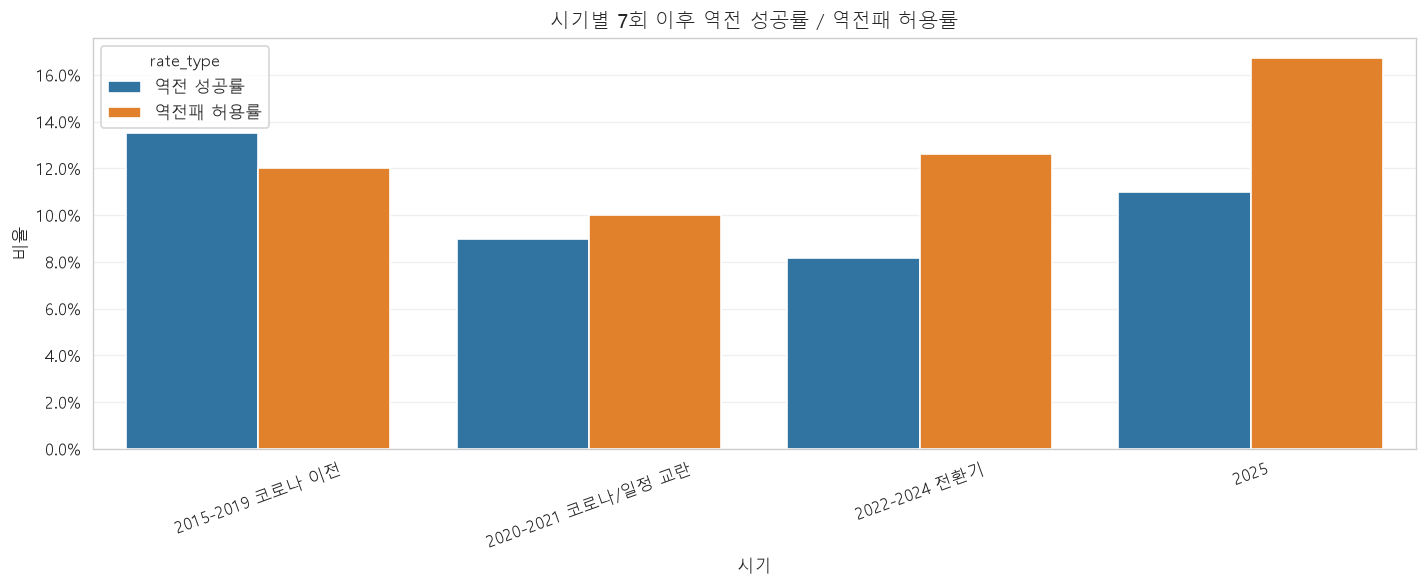

In [88]:
plot_period = period_summary.melt(
    id_vars=["team_code", "period"],
    value_vars=["comeback_rate", "collapse_rate"],
    var_name="rate_type",
    value_name="rate"
)

plot_period["rate_type"] = plot_period["rate_type"].map({
    "comeback_rate": "역전 성공률",
    "collapse_rate": "역전패 허용률"
})

plt.figure(figsize=(12, 5))

sns.barplot(
    data=plot_period,
    x="period",
    y="rate",
    hue="rate_type",
    errorbar=None
)

plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.title("시기별 7회 이후 역전 성공률 / 역전패 허용률")
plt.xlabel("시기")
plt.ylabel("비율")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

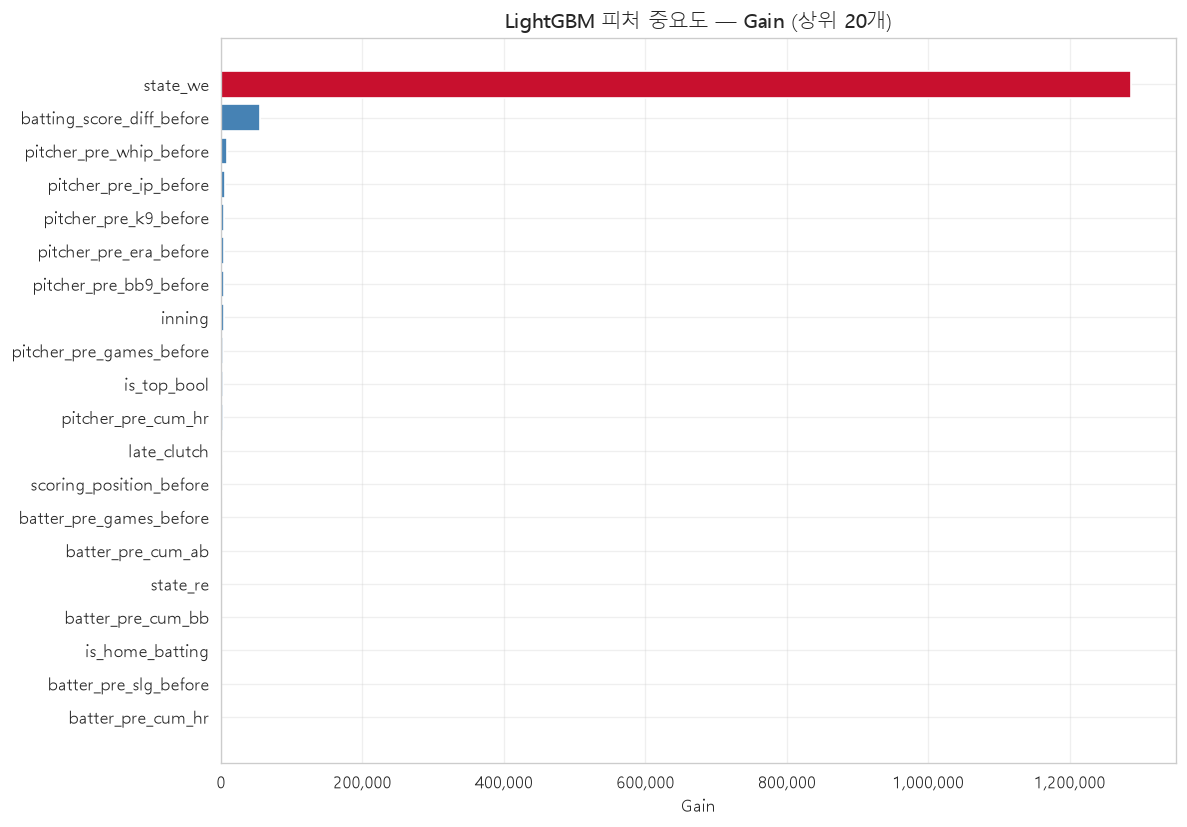

In [44]:
# 피처 중요도 (학습 결과)
try:
    fi = pd.read_csv('../kbo_pipeline/models/feature_importance.csv')
    fi_top = fi.sort_values('importance_gain', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bar_colors = ['#C8102E'] + ['steelblue'] * (len(fi_top) - 1)
    ax.barh(fi_top['feature'][::-1], fi_top['importance_gain'][::-1],
            color=bar_colors[::-1])
    ax.set_title('LightGBM 피처 중요도 — Gain (상위 20개)')
    ax.set_xlabel('Gain')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('feature_importance.csv 없음 — run_train_models.py 먼저 실행 필요')

---
## 4단계 — WE/RE 상태 공간 시각화 (`we_table.csv`, `re_table.csv`)

In [45]:
we = pd.read_csv(DATA / 'we_table.csv')
re = pd.read_csv(DATA / 're_table.csv')
print('WE 테이블:', we.shape, '  컬럼:', we.columns.tolist())
print('RE 테이블:', re.shape, '  컬럼:', re.columns.tolist())
we.head(5)

WE 테이블: (5273, 3)   컬럼: ['state_key', 'we', 'we_n']
RE 테이블: (24, 4)   컬럼: ['outs_before', 'base_state_before', 're', 're_n']


,state_key,we,we_n
0,1_bot_d-1_o0_b000,0.473026,1279
1,1_bot_d-1_o0_b001,0.472222,18
2,1_bot_d-1_o0_b010,0.606557,61
3,1_bot_d-1_o0_b011,NaN,8
4,1_bot_d-1_o0_b100,0.544192,396


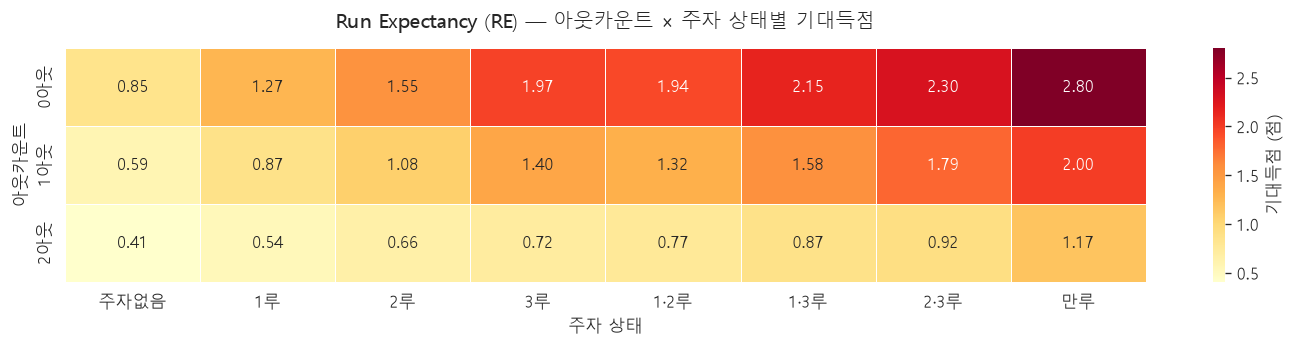

In [46]:
# RE 히트맵 (3아웃 × 8주자)
re_plot = re.copy()
re_plot['base_state_before'] = re_plot['base_state_before'].astype(str).str.zfill(3)
base_label = {
    '000':'주자없음','100':'1루','010':'2루','001':'3루',
    '110':'1·2루','101':'1·3루','011':'2·3루','111':'만루'
}
re_plot['주자상태'] = re_plot['base_state_before'].map(base_label)
re_plot['아웃'] = re_plot['outs_before'].astype(str) + '아웃'

col_order = ['주자없음','1루','2루','3루','1·2루','1·3루','2·3루','만루']
pivot_re = re_plot.pivot(index='아웃', columns='주자상태', values='re')
pivot_re = pivot_re[[c for c in col_order if c in pivot_re.columns]]

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot_re, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '기대득점 (점)'})
ax.set_title('Run Expectancy (RE) — 아웃카운트 × 주자 상태별 기대득점', pad=12)
ax.set_xlabel('주자 상태')
ax.set_ylabel('아웃카운트')
plt.tight_layout()
plt.show()

##### Run Expectancy, RE 히트맵 : 기대점수(득점 기대값)
1. WE : '이 상황에서 최종적으로 이길 확률'
2. RE : '이 상황부터 해당 이닝이 끝날 때가지 평균적으로 몇 점을 더 낼 것으로 기대되는가'
---
- 아웃카운트가 적을수록 기대득점이 높다.
- 주자가 많고 득점권에 가까울수록 기대 득점이 높다.
    - 그러나 동일한 득점권에서도 아웃카운트가 변수가 될 수 있다.
- 3루 주자의 가치가 꽤 크다(0아웃 2루:1.55, 0아웃 3루:1.97) : 3루 주자는 안타가 아니어도 이벤트로 득점이 가능하기 때문으로 해석할 수 있다.
- RE는 특정 아웃카운트와 주자 상태에서 이닝 종료 전까지 기대되는 평균 추가 득점을 의미한다. 결론적으로 히트맵은 주자가 많고, 아웃이 적을수록 기대득점이 높다는 보편적으로 통용되는 상식을 재확인 시켜준다고 볼 수 있다. 

In [47]:
# WE 키 파싱: {이닝}_{top/bot}_d{점수차}_o{아웃}_b{주자}
we_valid = we[we['we_n'] >= 10].copy()
parts = we_valid['state_key'].str.extract(
    r'^(?P<이닝>\d+)_(?P<초말>[^_]+)_d(?P<점수차>-?\d+)_o(?P<아웃>\d+)_b(?P<주자>\d+)$'
)
we_valid = pd.concat([we_valid, parts], axis=1)
we_valid['이닝']  = we_valid['이닝'].astype(int)
we_valid['점수차'] = we_valid['점수차'].astype(int)
we_valid['아웃']  = we_valid['아웃'].astype(int)
we_valid['초말']  = we_valid['초말'].map({'top':'초(원정)','bot':'말(홈)'})
print(f'파싱 성공: {we_valid["이닝"].notna().sum():,}개')
we_valid.head(3)

파싱 성공: 4,495개


,state_key,we,we_n,이닝,초말,점수차,아웃,주자
0,1_bot_d-1_o0_b000,0.473026,1279,1,말(홈),-1,0,000
1,1_bot_d-1_o0_b001,0.472222,18,1,말(홈),-1,0,001
2,1_bot_d-1_o0_b010,0.606557,61,1,말(홈),-1,0,010


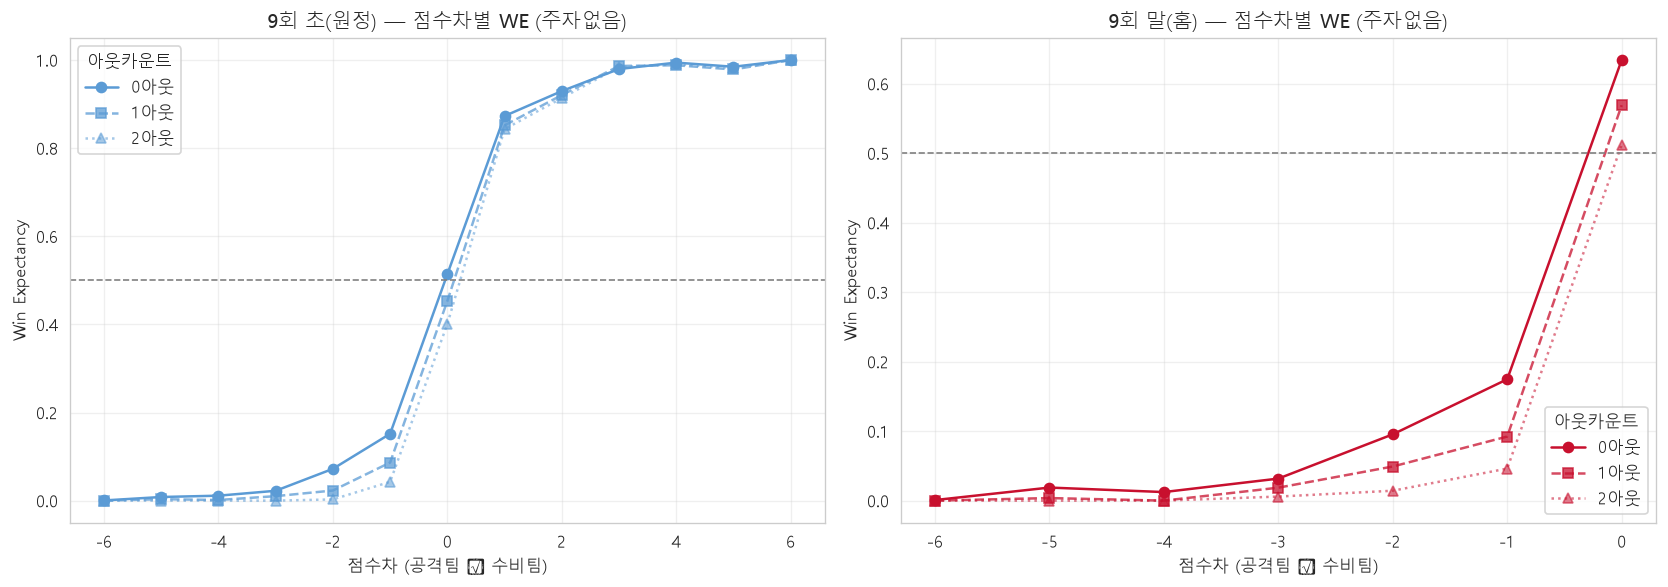

In [48]:
# 9회 주자없음 기준 — 점수차·아웃별 WE
subset = we_valid[(we_valid['이닝'] == 9) & (we_valid['주자'] == '000')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (side, color), ax in zip([('초(원정)','#5B9BD5'), ('말(홈)','#C8102E')], axes):
    s = subset[subset['초말'] == side].sort_values('점수차')
    for outs_val, (style, alpha) in enumerate([('o-', 1.0), ('s--', 0.75), ('^:', 0.55)]):
        ss = s[s['아웃'] == outs_val]
        if len(ss):
            ax.plot(ss['점수차'], ss['we'], style, color=color, alpha=alpha,
                    label=f'{outs_val}아웃')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'9회 {side} — 점수차별 WE (주자없음)')
    ax.set_xlabel('점수차 (공격팀 − 수비팀)')
    ax.set_ylabel('Win Expectancy')
    ax.legend(title='아웃카운트')

plt.tight_layout()
plt.show()

##### 9이닝 경기에서 초 / 말 비교
1. (왼쪽) 9회 초 원정 공격(점수를 낸 후에도 공격을 막아야 하는 상황) , (오른쪽) 9회 말 홈 공격(점수만 내면 바로 끝낼 수 있는 상황)
2. (왼쪽) 9회 초 원정팀이 공격 중일 때 점수차별 승리 확률(점수차, x = 공격팀(원정) 점수 - 수비팀(홈팀) 점수, 공격팀 기준)
    - 9회 초 이기 때문에 공격을 마친 후에도 홈팀 공격을 막아야 한다. 따라서 아웃카운트가 늘어날수록 승률이 떨어지는 것을 볼 수 있다.
    - 반면 원정팀이 9회초에 이미 1점 앞서고 있으면, 공격 상황의 아웃카운트보다 리드 자체가 훨씬 중요해지는 것을 볼 수 있다.
3. (오른쪽) 9회 말 홈팀 공격 점수차별 승리 확률(점수차, x = 공격팀(홈팀) 점수 - 수비팀(원정) 점수, 공격팀 기준)
    - 9회 말 홈팀의 점수차가 + 상황이라면 경기 진행에 의미가 없기 때문에 그래프에 표현되지 않음.
    - 1점인 상황과 동점인 상황일 때 승률이 급격한 차이를 보이는 것은 홈팀이 한 점만 내도 이길 수 있는 상황을 보여주는 것으로 해석할 수 있다.
4. 공통적으로 아웃카운트가 늘어나면 WE는 낮아진다.

---

- 요약하자면 9회 초는 “앞서야 산다”, 9회 말은 “동점만 돼도 홈팀에게 끝내기 프리미엄이 붙는다.”

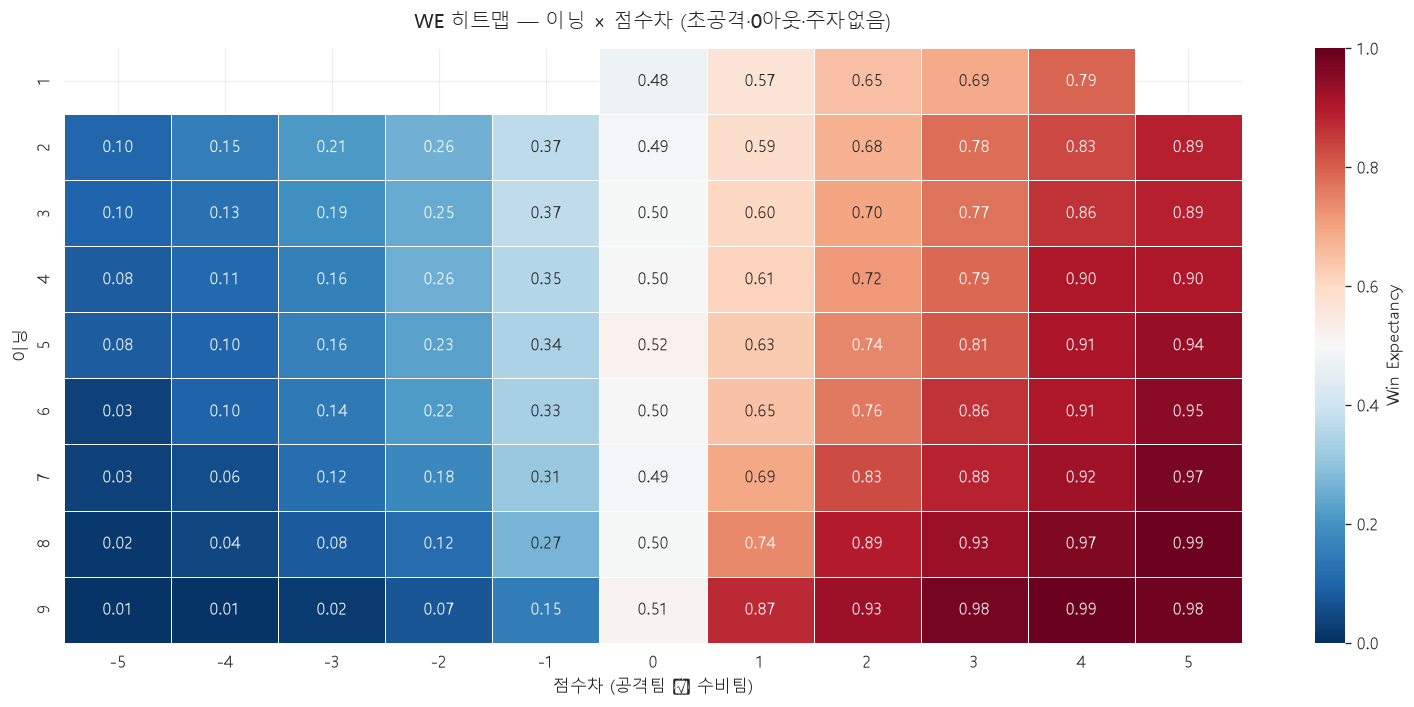

In [49]:
# WE 히트맵 — 이닝 × 점수차 (초공격, 0아웃, 주자없음)
pivot_we = (
    we_valid[
        (we_valid['초말'] == '초(원정)') &
        (we_valid['아웃'] == 0) &
        (we_valid['주자'] == '000')
    ]
    .pivot_table(index='이닝', columns='점수차', values='we')
)
# 점수차 ±5 범위만
cols_show = sorted([c for c in pivot_we.columns if -5 <= c <= 5])
pivot_we  = pivot_we[cols_show]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_we, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0.5, vmin=0, vmax=1, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Win Expectancy'})
ax.set_title('WE 히트맵 — 이닝 × 점수차 (초공격·0아웃·주자없음)', pad=12)
ax.set_xlabel('점수차 (공격팀 − 수비팀)')
ax.set_ylabel('이닝')
plt.tight_layout()
plt.show()

##### 이닝·점수차 별 공격팀이 최종적으로 이길 확률
1. 점수차가 커질수록 승률이 커진다.
2. 후반으로 갈수록 동일한 점수차의 의미가 커진다. (동점 상황에서는 거의 반반확률)
---
- 히트맵은 이닝과 공격팀 기준 점수차에 따른 Win Expectancy(WE)를 표현했다. 점수차가 공격팀에게 유리할수록 승리확률은 높아지고, 불리할수록 낮아지는 뚜렷한 패턴이 나타난다. 또한 같은 점수차라도 경기 후반으로 갈수록 승리확률이 더 극단적으로 변한다. 예를 들어 +1점 리드는 2회에는 약 0.59 수준이지만 9회에는 약 0.87까지 상승한다. 반대로 -1점 열세는 2회에는 약 0.37이지만 9회에는 약 0.15까지 낮아진다. 이는 야구에서 남은 공격 기회가 줄어들수록 현재 점수차의 영향력이 커진다는 것을 보여준다.

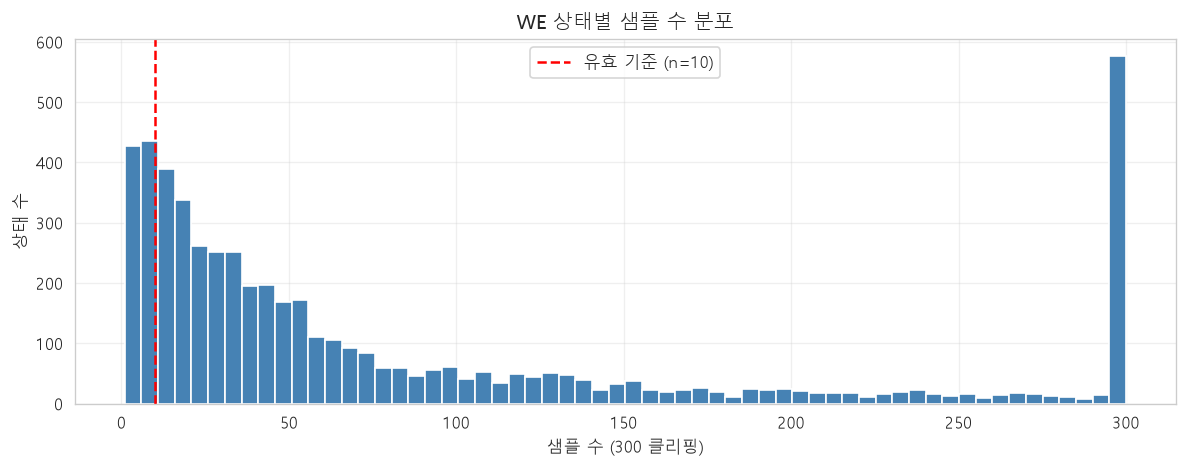

총 상태: 5,273  /  유효(n≥10): 4,495 (85.2%)


In [50]:
# WE 샘플 수 분포 (신뢰도)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(we['we_n'].clip(0, 300), bins=60, color='steelblue', edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='유효 기준 (n=10)')
ax.set_title('WE 상태별 샘플 수 분포')
ax.set_xlabel('샘플 수 (300 클리핑)')
ax.set_ylabel('상태 수')
ax.legend()
plt.tight_layout()
plt.show()
print(f'총 상태: {len(we):,}  /  유효(n≥10): {(we["we_n"]>=10).sum():,} ({(we["we_n"]>=10).mean()*100:.1f}%)')

---
## 요약

| 분석 항목 | 주요 인사이트 |
|-----------|---------------|
| 데이터 범위 | 2015~2025 시즌, 경기 9,372개, 타석 66만+ |
| 라벨 균형 | 공격팀 승리 ≈ 50% — 균형 잡힌 이진 분류 문제 |
| 핵심 피처 | state_we (gain 압도적 1위) — 이닝·점수차·아웃·주자 복합 사전 확률 |
| 투수 영향 | ERA/WHIP/K9 등 투수 스탯이 2~8위 — 투수 교체 의사결정에 중요 |
| WE 패턴 | 9회 동점 말 공격 WE ≈ 0.6+ (홈 어드밴티지 뚜렷) |
| RE 패턴 | 만루 0아웃이 기대득점 최대, 주자없음 2아웃이 최소 |